In [4]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *


Loading DLC 2.3.0...
DLC loaded in light mode; you cannot use any GUI (labeling, relabeling and standalone GUI)


In [2]:
import numpy as np

def find_event_frames(video_timestamps, event_timestamps):
    """
    Find which events occurred during the video and their corresponding video frames.
    Returns (None, None) if no events are found within the video duration.
    
    Args:
        video_timestamps (array-like): Monotonically increasing array of timestamps for each video frame.
        event_timestamps (array-like): Array of timestamps when events occurred.
        
    Returns:
        tuple: (event_indices, frame_indices) or (None, None) if no events found
               - event_indices: Indices of the original event array that fall within video duration
               - frame_indices: Corresponding video frame indices for these events
    """
    video_ts = np.asarray(video_timestamps)
    event_ts = np.asarray(event_timestamps)
    
    if len(video_ts) == 0 or len(event_ts) == 0:
        return None, None
    
    # Find which events are within video duration and their original indices
    valid_mask = (event_ts >= video_ts[0]) & (event_ts <= video_ts[-1])
    event_indices = np.where(valid_mask)[0]
    valid_events = event_ts[valid_mask]
    
    # Return None if no valid events found
    if len(valid_events) == 0:
        return None, None
    
    # Find corresponding frame indices
    frame_indices = np.searchsorted(video_ts, valid_events, side='right') - 1
    frame_indices = np.clip(frame_indices, 0, len(video_ts) - 1)
    
    return event_indices.tolist(), frame_indices.tolist()


In [4]:


def save_imu_eye_data(
    directory: str,
    animal: str,
    date: str = None,
    Usegood_reflec: bool = None,
    spot_count: int = None,
    Openephys_time: np.ndarray = None,
    dEye_dps: np.ndarray = None,
    dHead: np.ndarray = None,
    imuT: np.ndarray = None,
    dGaze: np.ndarray = None,
    gazeL_event: np.ndarray = None,
    gazeL_idx: np.ndarray = None,
    gazeR_event: np.ndarray = None,
    gazeR_idx: np.ndarray = None,
    compL_event: np.ndarray = None,
    compL_idx: np.ndarray = None,
    compR_event: np.ndarray = None,
    compR_idx: np.ndarray = None,
    filename: str = None,
    **extra_data
) -> str:
    """
    Save sensor data in NumPy .npz format without timestamp.
    
    Args:
        directory: Path to save directory
        animal: Animal ID (required)
        date: Recording date (optional, defaults to current date)
        All parameters can be scalars or numpy arrays
        **extra_data: Additional data to include
        
    Returns:
        str: Full path to saved .npz file
    """
    # Create base dictionary
    data_dict = {
        'animal': np.array(animal),
        'date': np.array(date if date else datetime.now().strftime("%Y-%m-%d")),
    }
    
    # Add all sensor data
    sensor_params = {
        'Usegood_reflec': Usegood_reflec,
        'spot_count':spot_count,
        'Openephys_time':Openephys_time,
        'dEye_dps': dEye_dps,
        'dHead': dHead,
        'imuT': imuT,
        'dGaze': dGaze,
        'gazeL_event': gazeL_event,
        'gazeL_idx': gazeL_idx,
        'gazeR_event': gazeR_event,
        'gazeR_idx': gazeR_idx,
        'compL_event': compL_event,
        'compL_idx': compL_idx,
        'compR_event': compR_event,
        'compR_idx': compR_idx,
        **extra_data
    }
    
    # Convert all values to numpy arrays
    for key, value in sensor_params.items():
        if value is not None:
            data_dict[key] = np.array(value)
    
    # Create directory if needed
    os.makedirs(directory, exist_ok=True)
    
    # Set default filename
    if filename is None:
        filename = f"{animal}_{data_dict['date'].item().replace('-', '')}.npz"
    elif not filename.endswith('.npz'):
        filename += '.npz'
    
    # Save in compressed numpy format
    filepath = os.path.join(directory, filename)
    np.savez_compressed(filepath, **data_dict)
    
    return filepath

In [ ]:
df1 = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\041825\F3LILT\oa_cam\cluster_F3LILT_041825_oa.h5")

In [ ]:
df1 = pd.read_hdf( r"\\goeppert\Vol2\mike\recordings\042525\F3LITT\oa_cam1\cluster_F3LITT_042525_oa.h5")

In [ ]:
df1 = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\042525\F3LILT\oa_cam\cluster_F3LILT_042525_oa.h5")

In [3]:
df1 = pd.read_hdf(
    r'\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\cluster_F3LILT_050725_oa.h5')

In [ ]:
df1 = pd.read_hdf(
    r'\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\cluster_F3LITT_050725_oa.h5')

In [ ]:

#session information 

session_date = '050725' 
animal_ID = 'F3LILT'
session_ID = 'oa_cam'
Rig_ID = 'Rig2'

#import IMU data  

imu_timestamps_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) + '_control_Rig2_' + str(session_ID) + '_Ephys_BonsaiBoardTS.csv'
imu_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) + '_control_Rig2_' + str(session_ID) + '_IMU.bin'

# Set up datatypes and names for each channel
dtypes = np.dtype([
    ("acc_x",np.uint16),
    ("acc_y",np.uint16),
    ("acc_z",np.uint16),
    ("none1",np.uint16),
    ("gyro_x",np.uint16),
    ("gyro_y",np.uint16),
    ("gyro_z",np.uint16),
    ("none2",np.uint16)
])


binary_in = pd.DataFrame(np.fromfile(imu_path, dtypes, -1, ''))
binary_in = binary_in.drop(columns=['none1','none2'])


# Convert to - 5V to + 5V (from ints)
data = 10 * (binary_in.astype(float)/(2**16) - 0.5)

# Downsample in time dimension
imu_samprate = 30000 # fixed constant
imu_dwnsmpl = 100 # imu_samprate is 30000, and we are using 100, therefore making it 30000/100 = 300hz. 
                  # if you want to boost up the temporal resolution up to 500hz, you can use 60.

data = data.iloc[::imu_dwnsmpl]

# Calculate new sample rate
samp_freq = imu_samprate / imu_dwnsmpl

# Alphabetize columns
data = data.reindex(sorted(data.columns), axis=1)

# Read in timestamps
csv_data = pd.read_csv(imu_timestamps_path).squeeze()
pdtime = pd.DataFrame(read_timestamp_series(csv_data))

# Get first/last timepoint, num_samples
t0 = pdtime.iloc[0,0]
num_samp = np.size(data,0)

# Samples start at t0, and are acquired at rate of
# 'ephys_sample_rate'/ 'imu_downsample'
newtime = list(np.array(t0 + np.linspace(0, num_samp-1, num_samp) / samp_freq))


IMU = ImuOrientation()

# Convert accelerometer to g
zero_reading = 2.9
sensitivity = 1.6
acc = pd.DataFrame.to_numpy((data[['acc_x', 'acc_y', 'acc_z']]-zero_reading)*sensitivity)

# Convert gyro to deg/sec
gyro = pd.DataFrame.to_numpy((data[['gyro_x', 'gyro_y', 'gyro_z']] - pd.DataFrame.mean(data[['gyro_x', 'gyro_y', 'gyro_z']]))*400)

# Collect roll & pitch
roll_pitch = np.zeros([len(acc),2])
for x in range(len(acc)):
    roll_pitch[x,:] = IMU.process((acc[x],gyro[x])) # update by row
roll_pitch = pd.DataFrame(roll_pitch, columns=['roll','pitch'])

# Collect the data together
all_data = pd.concat([
    data.reset_index(),
    pd.DataFrame(acc).reset_index(),
    pd.DataFrame(gyro).reset_index(),
    roll_pitch
], axis=1).drop(labels='index',axis=1)

# Set up column names
all_data.columns = [
    'acc_x_raw','acc_y_raw','acc_z_raw',
    'gyro_x_raw','gyro_y_raw','gyro_z_raw',
    'acc_x','acc_y','acc_z',
    'gyro_x', 'gyro_y', 'gyro_z',
    'roll', 'pitch'
]

Text(0.5, 0, 'frame')

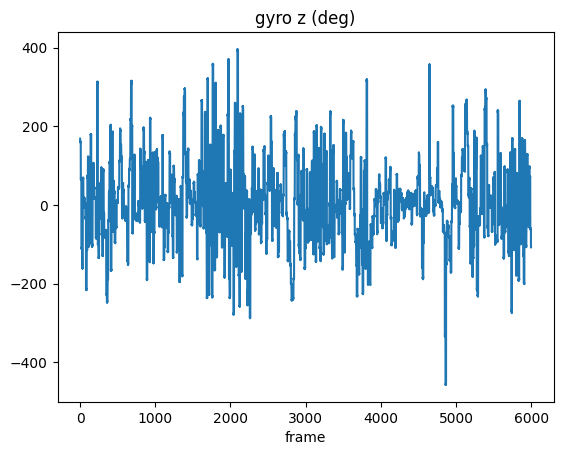

In [6]:
output_data = xr.DataArray(all_data, dims=['sample','channel'])
imu_data = output_data.assign_coords({'sample':newtime})

imuT_raw = imu_data.sample # imu timestamps

# Raw gyro values
gyro_x_raw = imu_data.sel(channel='gyro_x_raw').values
gyro_y_raw = imu_data.sel(channel='gyro_y_raw').values
gyro_z_raw = imu_data.sel(channel='gyro_z_raw').values

# Gyro values in degrees
gyro_x = imu_data.sel(channel='gyro_x').values
gyro_y = imu_data.sel(channel='gyro_y').values
gyro_z = imu_data.sel(channel='gyro_z').values

# Pitch and roll in deg
roll = imu_data.sel(channel='roll').values
pitch = imu_data.sel(channel='pitch').values

# figure of gyro z
plt.figure()
plt.plot(gyro_x[0:100*60])
plt.title('gyro z (deg)')
plt.xlabel('frame')

Text(0, 0.5, 'fraction of frames')

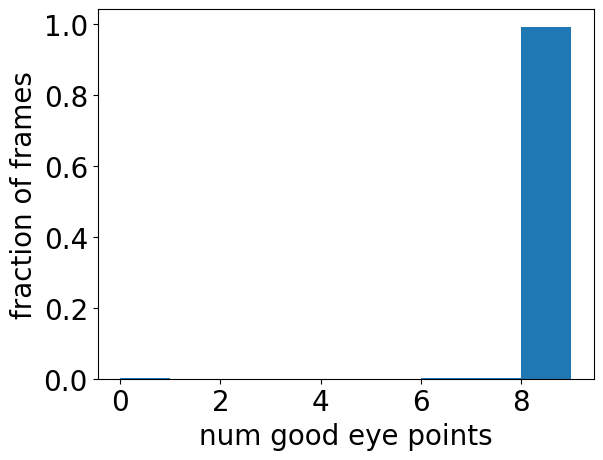

In [24]:
plt.figure()
plt.hist(pupil_count, bins=9,
                range=(0,9), density=True)
plt.xlabel('num good eye points')
plt.ylabel('fraction of frames')

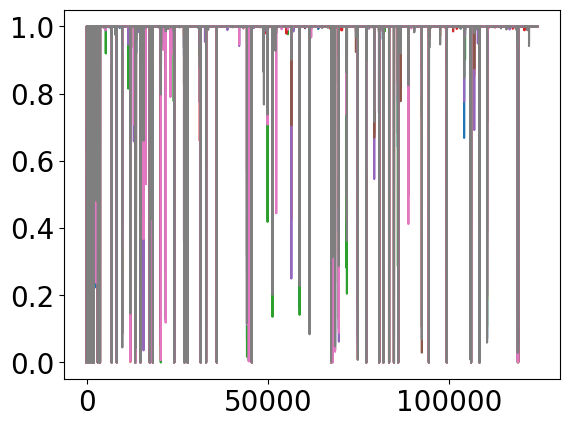

In [25]:
plt.plot(likelihood)

In [7]:
dlc_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_REYEdeinterDLC_resnet50_eye_tracking_050825May8shuffle1_1030000.h5'
eye_timestamp_path =  '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_REYE_BonsaiTS.csv'

pts, pt_names = open_dlc_h5(dlc_path)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
xrpts = xr.DataArray(pts, dims=['frame', 'point_loc'])

data = xrpts
names = list(data['point_loc'].values)
thresh = 0.99 #configuration value

x_locs = []
y_locs = []
likeli_locs = []

# seperate the lists of point names into x, y, and likelihood
for loc_num in range(0, len(names)):
    loc = names[loc_num]
    if '_x' in loc:
        x_locs.append(loc)
    elif '_y' in loc:
        y_locs.append(loc)
    elif 'likeli' in loc:
        likeli_locs.append(loc)

# get the xarray, split up into x, y,and likelihood
for loc_num in range(0, len(likeli_locs)):
    pt_loc = likeli_locs[loc_num]
    if loc_num == 0:
        likeli_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        likeli_pts = xr.concat([likeli_pts, data.sel(point_loc=pt_loc)],
                                dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(x_locs)):
    pt_loc = x_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        x_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        x_pts = xr.concat([x_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

for loc_num in range(0, len(y_locs)):
    pt_loc = y_locs[loc_num]
    # threshold from likelihood
    data.sel(point_loc=pt_loc)[data.sel(point_loc=pt_loc) < thresh] = np.nan
    if loc_num == 0:
        y_pts = data.sel(point_loc=pt_loc)
    elif loc_num > 0:
        y_pts = xr.concat([y_pts, data.sel(point_loc=pt_loc)],
                            dim='point_loc', fill_value=np.nan)

x_pts = xr.DataArray.squeeze(x_pts)
y_pts = xr.DataArray.squeeze(y_pts)
likeli_pts = xr.DataArray.squeeze(likeli_pts)

# convert to dataframe, transpose so points are columns
x_vals = xr.DataArray.to_pandas(x_pts).T
y_vals = xr.DataArray.to_pandas(y_pts).T
likeli_vals = xr.DataArray.to_pandas(likeli_pts).T
likelihood_in = likeli_vals.values

# Subtract center of IR light reflection from points around the pupil.

spot_xcent = np.mean(x_vals.iloc[:,-5:], 1)
spot_ycent = np.mean(y_vals.iloc[:,-5:], 1)
spot_likelihood = likelihood_in[:,-5:].copy()

likelihood = likelihood_in[:,:-5]

x_vals = x_vals.iloc[:,:-5].subtract(spot_xcent, axis=0)
y_vals = y_vals.iloc[:,:-5].subtract(spot_ycent, axis=0)

x_vals = x_vals.iloc[:,:-2]
y_vals = y_vals.iloc[:,:-2]
likelihood = likelihood[:,:-2]

pupil_count = np.sum(likelihood >= thresh, 1)

spot_count = np.sum(spot_likelihood >= thresh, 1)

usegood_eye = (pupil_count >= 7) &               \
                (spot_count >= 5)

usegood_eyecalib = (pupil_count >= 8) &          \
                    (spot_count >= 5)

usegood_reflec = (spot_count >=5)


# Threshold out pts more than a given distance away from nanmean of that point
std_thresh_x = np.empty(np.shape(x_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = x_vals.iloc[:,point_loc]
    std_thresh_x[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 24

std_thresh_y = np.empty(np.shape(y_vals))

for point_loc in range(0,np.size(x_vals, 1)):
    _val = y_vals.iloc[:,point_loc]
    std_thresh_y[:,point_loc] = (np.abs(np.nanmean(_val) - _val)                \
                    / 24) > 4.1

std_thresh_x = np.nanmean(std_thresh_x, 1)
std_thresh_y = np.nanmean(std_thresh_y, 1)

x_vals[std_thresh_x > 0] = np.nan
y_vals[std_thresh_y > 0] = np.nan

cols = [
    'X0',           # 0
    'Y0',           # 1
    'F',            # 2
    'a',            # 3
    'b',            # 4
    'long_axis',    # 5
    'short_axis',   # 6
    'angle_to_x',   # 7
    'angle_from_x', # 8
    'cos_phi',      # 9
    'sin_phi',      # 10
    'X0_in',        # 11
    'Y0_in',        # 12
    'phi'           # 13
]

In [8]:
#Fit ellipse

ellipse = np.empty([len(usegood_eye), 14])

# Step through each frame, fit an ellipse to points, and add ellipse
# parameters to array with data for all frames together.
linalgerror = 0
for step in tqdm(range(0,len(usegood_eye))):
    
    if usegood_eye[step] == True:
        
        try:

            e_t = fit_ellipse(x_vals.iloc[step].values,
                                    y_vals.iloc[step].values)
            
            ellipse[step] = [
                e_t['X0'],              # 0
                e_t['Y0'],              # 1
                e_t['F'],               # 2
                e_t['a'],               # 3
                e_t['b'],               # 4
                e_t['long_axis'],       # 5
                e_t['short_axis'],      # 6
                e_t['angle_to_x'],      # 7
                e_t['angle_from_x'],    # 8
                e_t['cos_phi'],         # 9
                e_t['sin_phi'],         # 10
                e_t['X0_in'],           # 11
                e_t['Y0_in'],           # 12
                e_t['phi']              # 13
            ]
        
        except np.linalg.LinAlgError as e:

            linalgerror = linalgerror + 1
            ellipse[step] = list(np.ones([len(cols)]) * np.nan)
    
    elif usegood_eye[step] == False:

        ellipse[step] = list(np.ones([len(cols)]) * np.nan)

print('LinAlg error count = ' + str(linalgerror))

# List of all places where the ellipse meets threshold
R = np.linspace(0, 2*np.pi, 100)

# (short axis / long axis) < thresh
usegood_ellipcalb = np.where((usegood_eyecalib == True)                     \
        & ((ellipse[:,6] / ellipse[:,5]) < 0.85))

# Limit number of frames used for calibration
f_lim = 50000
if np.size(usegood_ellipcalb,1) > f_lim:
    shortlist = sorted(np.random.choice(usegood_ellipcalb[0],
                        size=f_lim, replace=False))
else:
    shortlist = usegood_ellipcalb

# Find camera center
A = np.vstack([np.cos(ellipse[shortlist,7]),
                np.sin(ellipse[shortlist,7])])

b = np.expand_dims(np.diag(A.T @ np.squeeze(ellipse[shortlist, 11:13].T)), axis=1)

cam_cent = np.linalg.inv(A @ A.T) @ A @ b

# Ellipticity and scale
ellipticity = (ellipse[shortlist,6] / ellipse[shortlist,5]).T

try:
    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=0)))       \
    / np.sum(1 - (ellipticity)**2)

except ValueError:

    scale = np.nansum(np.sqrt(1 - (ellipticity)**2) *                       \
    (np.linalg.norm(ellipse[shortlist, 11:13] - cam_cent.T, axis=1)))       \
    / np.sum(1 - (ellipticity)**2)


# Horizontal orientation (THETA)
theta = np.arcsin((ellipse[:,11] - cam_cent[0]) / scale)

# Vertical orientation (PHI)
phi = np.arcsin((ellipse[:,12] - cam_cent[1]) / np.cos(theta) / scale)

100%|██████████| 124408/124408 [00:49<00:00, 2520.64it/s]


LinAlg error count = 0


In [9]:
# Organize data to return as an xarray of most essential parameters
ellipse_df = pd.DataFrame({
    'theta':list(theta),
    'phi':list(phi),
    'longaxis':list(ellipse[:,5]),
    'shortaxis':list(ellipse[:,6]),
    'X0':list(ellipse[:,11]),
    'Y0':list(ellipse[:,12]),
    'ellipse_phi':list(ellipse[:,7])
})

ellipse_param_names = [
    'theta',
    'phi',
    'longaxis',
    'shortaxis',
    'X0',
    'Y0',
    'ellipse_phi'
]

ellipse_out = xr.DataArray(ellipse_df,
    coords=[('frame', range(0, len(ellipse_df))),
            ('ellipse_params', ellipse_param_names)],
    dims=['frame', 'ellipse_params'])

ellipse_out.attrs['cam_center_x'] = cam_cent[0,0]
ellipse_out.attrs['cam_center_y'] = cam_cent[1,0]

In [ ]:

top_dlc_path = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_TOP1DLC_resnet50_obstacle_avoidance_withcam_041825Apr18shuffle1_650000.h5'
top_timestamp_path =  '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID) + '/' + str(session_date) + '_' + str(animal_ID) +'_control_'+str(Rig_ID)+'_' + str(session_ID) + '_TOP1_BonsaiTS.csv'


topT = read_timestamp_file(top_timestamp_path, len(pts))


In [11]:
shifted_head = 0
still_gaze = 120
shifted_gaze = 200

th = np.rad2deg(ellipse_out.sel(ellipse_params = 'theta').values)
theta = th - np.nanmean(th)
dEye = np.diff(theta)

In [30]:
##gyro_z
Openephys_time = read_timestamp_file(imu_timestamps_path)
OpenephysT0 = Openephys_time[0]

# match timestamps
pts, pt_names = open_dlc_h5(dlc_path)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
eyeT = eyeT - OpenephysT0
imuT_raw = imu_data.sample
imuT_raw = imuT_raw - OpenephysT0
topT = read_timestamp_file(top_timestamp_path, len(pts))
topT = topT - OpenephysT0

# account for the drift (it is a system known issue that open ephys box has a weird drift phenomenon)

lag_range = np.arange(-0.2, 0.2, 0.002)
cc = np.zeros(np.shape(lag_range))

t1 = np.arange(5, len(dEye)/60 - 120, 20).astype(int)
t2 = t1 + 60
offset = np.zeros(np.shape(t1))
ccmax = np.zeros(np.shape(t1))
imu_interp = scipy.interpolate.interp1d(imuT_raw, gyro_z)

for tstart in tqdm(range(len(t1))):

    for l in range(len(lag_range)):
        try:
            c, lag = nanxcorr(-dEye[t1[tstart]*60 : t2[tstart]*60],
                        imu_interp(eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                        1)
            cc[l] = c[1]

        except:
            cc[l] = np.nan

    offset[tstart] = lag_range[np.argmax(cc)]    
    ccmax[tstart] = np.max(cc)

offset[ccmax<0.1] = np.nan

# Fit regression to timing drift
model = sklearn.linear_model.LinearRegression()
dataT = np.array(eyeT[t1*60 + 30*60])

model.fit(dataT[~np.isnan(offset)].reshape(-1,1),
            offset[~np.isnan(offset)]) 
            
ephys_offset = model.intercept_
ephys_drift_rate = model.coef_

imuT = imuT_raw - (ephys_offset + imuT_raw * ephys_drift_rate)

tmp_eyeT = eyeT.flatten()[:-1]

# calculating eye movements

eye_use_thresh = 50
theta[np.where(abs(theta) > eye_use_thresh)] = np.nan

dEye_dps = dEye / np.diff(eyeT) # deg/sec

dEye_dps[np.where(abs(dEye_dps) >1500)] = np.nan

# Extract gaze/compensatory trials
dHead = scipy.interpolate.interp1d(imuT,
                                    gyro_z,
                                    bounds_error=False)(eyeT)[:-1]
dGaze = dHead + dEye_dps


gazeL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze > shifted_gaze)]
gazeR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze < -shifted_gaze)]

compL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze < still_gaze) &           \
                 (dGaze > -still_gaze)]
compR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze > -still_gaze) &          \
                 (dGaze < still_gaze)]


# Eliminating compensatory eye/head movements which fall right after gaze-shifting eye/head movements
#compL = drop_nearby_events(compL, gazeL)  
#compR = drop_nearby_events(compR, gazeR)

# Eliminate saccades repeated over sequential camera frames
gazeL_event = drop_repeat_events(gazeL)
gazeR_event = drop_repeat_events(gazeR)
compL_event = drop_repeat_events(compL)
compR_event = drop_repeat_events(compR)

# Extract idx

_, gazeL_idx, _ = np.intersect1d(tmp_eyeT,gazeL_event, return_indices=True)
_, gazeR_idx, _ = np.intersect1d(tmp_eyeT,gazeR_event, return_indices=True)
_, compL_idx, _ = np.intersect1d(tmp_eyeT,compL_event, return_indices=True)
_, compR_idx, _ = np.intersect1d(tmp_eyeT,compR_event, return_indices=True)


100%|██████████| 98/98 [01:52<00:00,  1.15s/it]


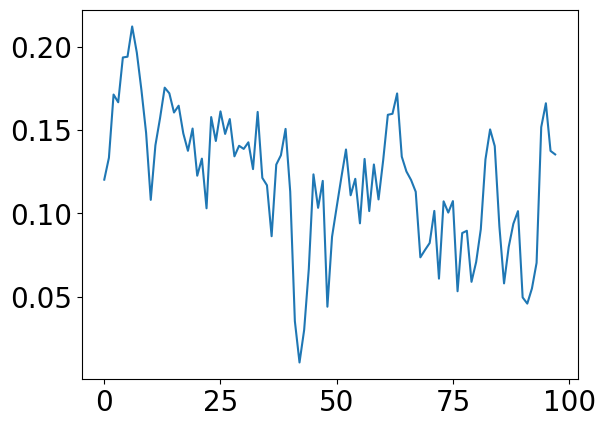

In [31]:
plt.plot(ccmax)

In [32]:
offset

array([ 0.156,  0.154,  0.148,  0.142,  0.144,  0.126,  0.138,  0.138,
        0.13 ,  0.128,  0.124,  0.12 ,  0.118,  0.118,  0.112,  0.112,
        0.104,  0.106,  0.104,  0.102,  0.102,  0.094,  0.086,  0.082,
        0.086,  0.084,  0.082,  0.078,  0.07 ,  0.07 ,  0.068,  0.062,
        0.062,  0.058,  0.056,  0.054,    nan,  0.038,  0.03 ,  0.028,
        0.028,    nan,    nan,    nan,    nan,  0.02 ,  0.02 ,  0.018,
          nan,    nan,  0.012, -0.002, -0.002, -0.01 , -0.016,    nan,
       -0.012, -0.012, -0.02 , -0.024, -0.03 , -0.032, -0.038, -0.04 ,
       -0.038, -0.04 , -0.042, -0.044,    nan,    nan,    nan, -0.052,
          nan, -0.064, -0.118, -0.064,    nan,    nan,    nan,    nan,
          nan,    nan, -0.084, -0.092, -0.094,    nan,    nan,    nan,
          nan, -0.134,    nan,    nan,    nan,    nan, -0.124, -0.124,
       -0.132, -0.138])

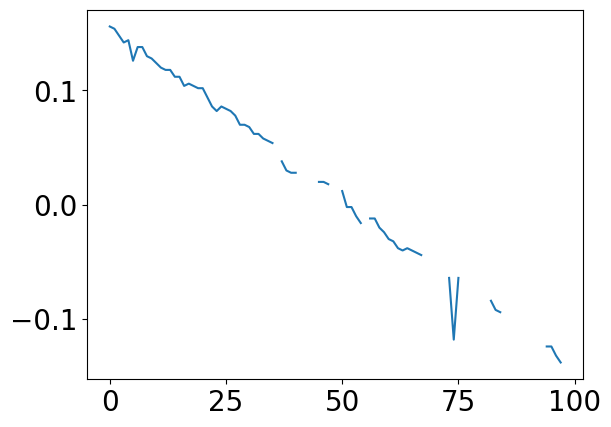

In [33]:
plt.plot(offset)

In [38]:
##gyro x for timestamp correction 
## gyro z for dHead 
Openephys_time = read_timestamp_file(imu_timestamps_path)
OpenephysT0 = Openephys_time[0]

# match timestamps
pts, pt_names = open_dlc_h5(dlc_path)
eyeT = read_timestamp_file(eye_timestamp_path, len(pts))
eyeT = eyeT - OpenephysT0
imuT_raw = imu_data.sample
imuT_raw = imuT_raw - OpenephysT0
topT = read_timestamp_file(top_timestamp_path, len(pts))
topT = topT - OpenephysT0

# account for the drift (it is a system known issue that open ephys box has a weird drift phenomenon)

lag_range = np.arange(-0.2, 0.2, 0.002)
cc = np.zeros(np.shape(lag_range))

t1 = np.arange(5, len(dEye)/60 - 120, 20).astype(int)
t2 = t1 + 60
offset = np.zeros(np.shape(t1))
ccmax = np.zeros(np.shape(t1))
imu_interp = scipy.interpolate.interp1d(imuT_raw, gyro_x)

for tstart in tqdm(range(len(t1))):

    for l in range(len(lag_range)):
        try:
            c, lag = nanxcorr(-dEye[t1[tstart]*60 : t2[tstart]*60],
                        imu_interp(eyeT[t1[tstart]*60 : t2[tstart]*60]+lag_range[l]),
                        1)
            cc[l] = c[1]

        except:
            cc[l] = np.nan

    offset[tstart] = lag_range[np.argmax(cc)]    
    ccmax[tstart] = np.max(cc)

offset[ccmax<0.2] = np.nan

# Fit regression to timing drift
model = sklearn.linear_model.LinearRegression()
dataT = np.array(eyeT[t1*60 + 30*60])

model.fit(dataT[~np.isnan(offset)].reshape(-1,1),
            offset[~np.isnan(offset)]) 
            
ephys_offset = model.intercept_
ephys_drift_rate = model.coef_

imuT = imuT_raw - (ephys_offset + imuT_raw * ephys_drift_rate)

tmp_eyeT = eyeT.flatten()[:-1]

# calculating eye movements

eye_use_thresh = 50
theta[np.where(abs(theta) > eye_use_thresh)] = np.nan

dEye_dps = dEye / np.diff(eyeT) # deg/sec

dEye_dps[np.where(abs(dEye_dps) >1500)] = np.nan

# Extract gaze/compensatory trials
dHead = scipy.interpolate.interp1d(imuT,
                                    gyro_z,
                                    bounds_error=False)(eyeT)[:-1]
dGaze = dHead + dEye_dps


gazeL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze > shifted_gaze)]
gazeR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze < -shifted_gaze)]

compL = tmp_eyeT[(dHead > shifted_head) &         \
                 (dGaze < still_gaze) &           \
                 (dGaze > -still_gaze)]
compR = tmp_eyeT[(dHead < -shifted_head) &        \
                 (dGaze > -still_gaze) &          \
                 (dGaze < still_gaze)]


# Eliminating compensatory eye/head movements which fall right after gaze-shifting eye/head movements
#compL = drop_nearby_events(compL, gazeL)  
#compR = drop_nearby_events(compR, gazeR)

# Eliminate saccades repeated over sequential camera frames
gazeL_event = drop_repeat_events(gazeL)
gazeR_event = drop_repeat_events(gazeR)
compL_event = drop_repeat_events(compL)
compR_event = drop_repeat_events(compR)

# Extract idx

_, gazeL_idx, _ = np.intersect1d(tmp_eyeT,gazeL_event, return_indices=True)
_, gazeR_idx, _ = np.intersect1d(tmp_eyeT,gazeR_event, return_indices=True)
_, compL_idx, _ = np.intersect1d(tmp_eyeT,compL_event, return_indices=True)
_, compR_idx, _ = np.intersect1d(tmp_eyeT,compR_event, return_indices=True)


100%|██████████| 98/98 [02:00<00:00,  1.23s/it]


In [44]:
print(ephys_offset,ephys_drift_rate)

0.1603040528589701 [-0.00014876]


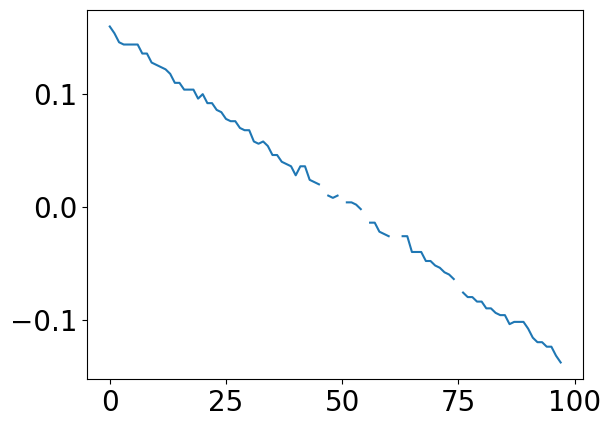

In [ ]:
plt.plot(offset)
plt.title('offset')

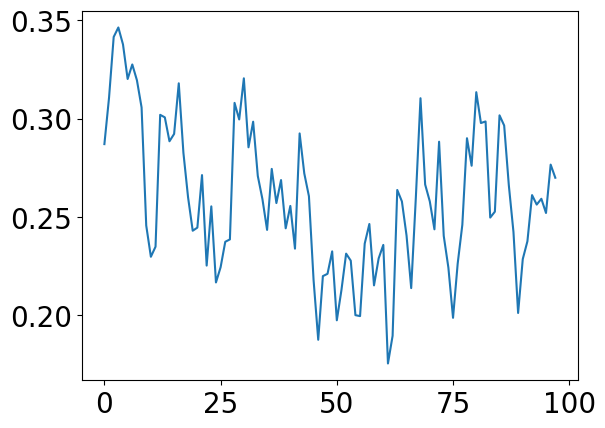

In [40]:
plt.plot(ccmax)

In [57]:
usegood_ellipcalb

(array([     3,      4,      5, ..., 124405, 124406, 124407], dtype=int64),)

In [55]:
usegood_ellipcalb[0]

array([     3,      4,      5, ..., 124405, 124406, 124407], dtype=int64)

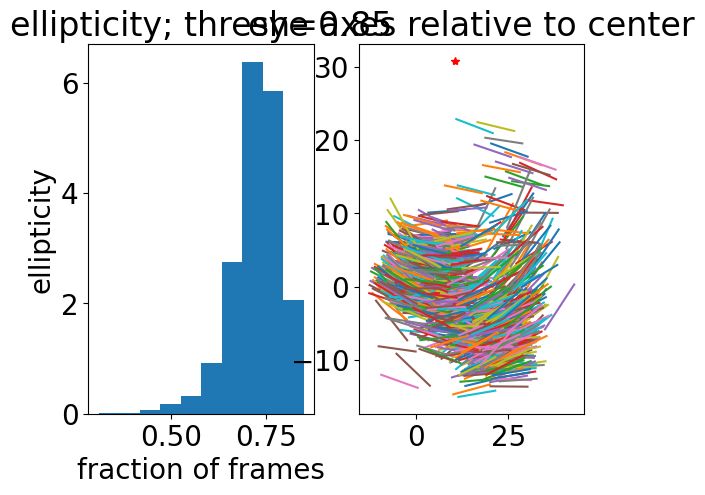

In [56]:

# Ellipticity histogram
fig_dwnsmpl = 100

try:
    # Hist of ellipticity
    plt.subplot(1,2,1)
    plt.hist(ellipticity, density=True)
    plt.title('ellipticity; thresh='+str(0.85))
    plt.ylabel('ellipticity')
    plt.xlabel('fraction of frames')
    
    # Eye axes relative to center
    w = ellipse[:,7]
    plt.subplot(1,2,2)
    for i in range(0,len(usegood_ellipcalb)):

        _show = usegood_ellipcalb[0][i::fig_dwnsmpl]

        plt.plot((ellipse[_show,11] + [-5 * np.cos(w[_show]),       \
                    5 * np.cos(w[_show])]),                            \
                    (ellipse[_show,12] + [-5*np.sin(w[_show]),         \
                    5*np.sin(w[_show])]))

    plt.plot(cam_cent[0], cam_cent[1], 'r*')
    plt.title('eye axes relative to center')

except Exception as e:
    print('Figure error in plots of ellipticity and axes relative to center')
    print(e)

In [70]:
fig_dwnsmpl

100

In [ ]:
# Check calibration
try:

    xvals = np.linalg.norm(ellipse[usegood_eyecalib, 11:13].T - cam_cent, axis=0)

    yvals = scale * np.sqrt( 1 - (ellipse[usegood_eyecalib, 6]              \
                                / ellipse[usegood_eyecalib, 5]) **2)

    calib_mask = ~np.isnan(xvals) & ~np.isnan(yvals)

    slope, _, r_value, _, _ = scipy.stats.linregress(xvals[calib_mask],
                                                        yvals[calib_mask].T)

except ValueError:
    print('no good frames that meet criteria... check DLC tracking!')

Text(0, 0.5, 'scale * ellipticity')

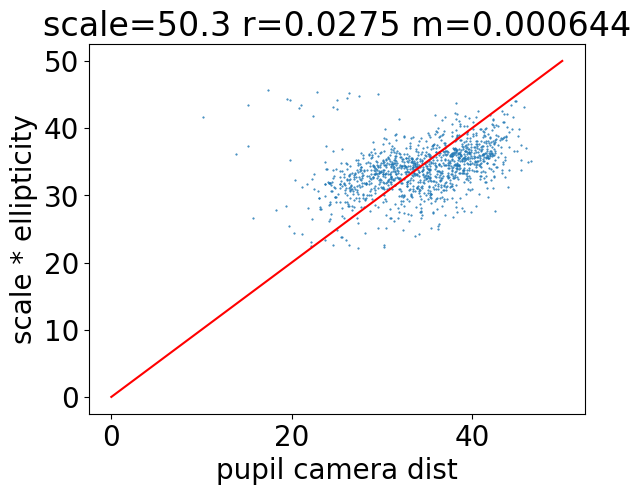

In [71]:
plt.figure()
plt.plot(xvals[::fig_dwnsmpl],
            yvals[::fig_dwnsmpl], '.', markersize=1)
plt.plot(np.linspace(0,50), np.linspace(0,50), 'r')
plt.title('scale={:.3} r={:.3} m={:.3}'.format(scale, r_value, slope))
plt.xlabel('pupil camera dist')
plt.ylabel('scale * ellipticity')

Text(0, 0.5, 'fraction of frames')

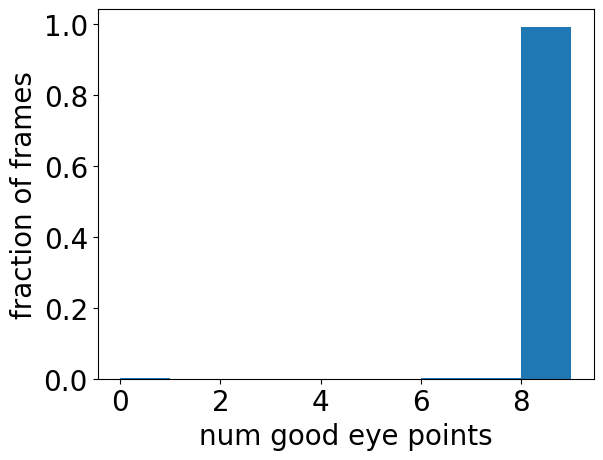

In [49]:
plt.figure()
plt.hist(pupil_count, bins=9,
                range=(0,9), density=True)
plt.xlabel('num good eye points')
plt.ylabel('fraction of frames')

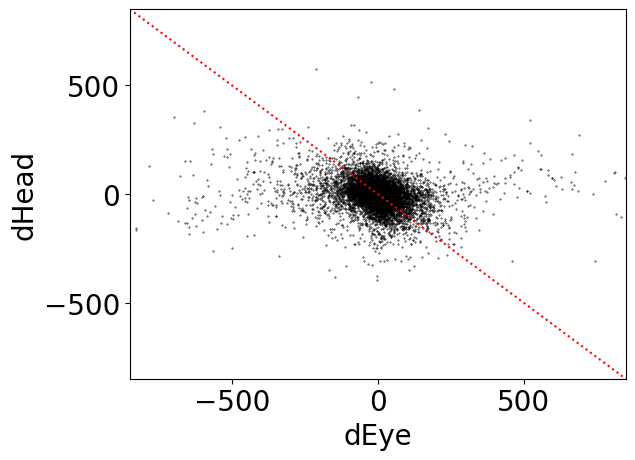

In [48]:
plt.plot(dEye_dps[::10], dHead[::10], 'k.',markersize = .7)
plt.xlabel('dEye')
plt.ylabel('dHead')
plt.xlim((-850,850))
plt.ylim((-850,850))
plt.plot([-850,850], [850,-850], 'r:')

Text(0, 0.5, 'fraction of frames')

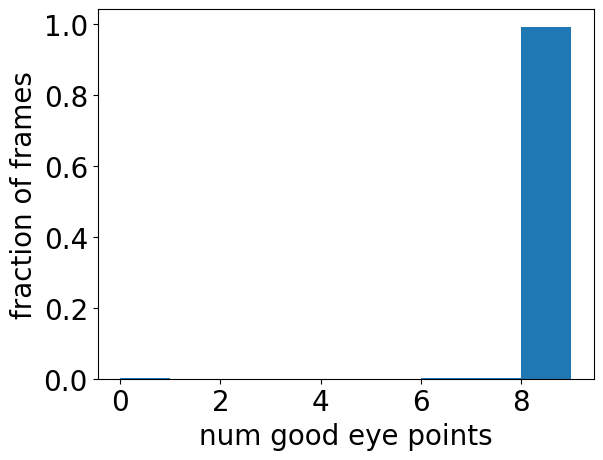

In [129]:
plt.figure()
plt.hist(pupil_count, bins=9,
                range=(0,9), density=True)
plt.xlabel('num good eye points')
plt.ylabel('fraction of frames')

In [130]:
plt.close()

In [ ]:
OpenephysT0

In [ ]:
imuT

In [ ]:
'//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID)

In [14]:
animal_directory = '//goeppert/Vol2/mike/recordings/' + str(session_date) + '/' + str(animal_ID) + '/' + str(session_ID)

save_imu_eye_data(directory=animal_directory,Openephys_time =Openephys_time,
                  animal=animal_ID, date=session_date,Usegood_reflec=usegood_reflec,spot_count=spot_count,
                  dEye_dps=dEye_dps,dHead=dHead,imuT=imuT,dGaze=dGaze,gazeL_event=gazeL_event,gazeL_idx=gazeL_idx,gazeR_event= gazeR_event,gazeR_idx=gazeR_idx,
                  compL_event=compL_event,compL_idx=compL_idx,compR_event = compR_event, compR_idx=compR_idx, filename= str(session_date)+ "_"+str(animal_ID)+"_imu_eyecam_dict")

'//goeppert/Vol2/mike/recordings/050725/F3LILT/oa_cam\\050725_F3LILT_imu_eyecam_dict.npz'

In [15]:
data = np.load(r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_imu_eyecam_dict.npz")

In [ ]:
data['Openephys_time']

In [ ]:
def find_closest(array, target):
    """
    Find the element in an array that is closest to the target float value.
    
    Parameters:
    array (list): List of numbers to search through
    target (float): The target value to find the closest element to
    
    Returns:
    The element in the array closest to the target value
    """
    if  array.size == 0:  # Handle empty array case
        raise ValueError("Input array must not be empty")
    
    # Initialize with first element
    closest = array[0]
    min_diff = abs(target - closest)
    
    for element in array[1:]:
        current_diff = abs(target - element)
        if current_diff < min_diff:
            min_diff = current_diff
            closest = element
    
    return closest,np.argwhere(array==closest)[0][0]

In [ ]:
import matplotlib.lines as mlines

In [ ]:
#trial = df1.sample(1)
for ind,row in trial.iterrows():

## correct top timestamps to ephuy board 
    trial_imu_corected = row.ts_trial_timestamps - OpenephysT0
## find frames that gaze and comp movements 
    gazeR_ind,r_ind = find_event_frames(trial_imu_corected, gazeR_event)
    gazeL_ind ,l_ind = find_event_frames(trial_imu_corected, gazeL_event)
    compR_ind,cr_ind = find_event_frames(trial_imu_corected, compR_event)
    compL_ind ,cl_ind = find_event_frames(trial_imu_corected, compL_event)
## plot trial trajectories 
    fig,axis = plt.subplots(2,2,figsize =[15,12])
    axis[0,0].plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm)
    left_gaze = mlines.Line2D([], [], color='k',
                          markersize=15, label='left_gaze')
    right_gaze = mlines.Line2D([], [], color='red',
                          markersize=15, label='right_gaze')
    axis[0,0].legend(handles = [left_gaze,right_gaze])

    axis[1,0].plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm)   
    left_comp = mlines.Line2D([], [], color='green',
                          markersize=15, label='left_comp')
    right_comp = mlines.Line2D([], [], color='purple',
                          markersize=15, label='right_comp')
    axis[1,0].legend(handles = [left_comp,right_comp])

## plot arena and obstacle     
    plot_arena(trial,axis[0,0],bottom=True)
    plot_arena(trial,axis[1,0],bottom=True)
    obstacle_x = [row.gt_obstacleTL_x_cm,
        row.gt_obstacleTR_x_cm,row.gt_obstacleTR_x_cm,
        row.gt_obstacleTL_x_cm,
        row.gt_obstacleTL_x_cm]
    obstacle_y = [row.gt_obstacleTL_y_cm,
        row.gt_obstacleTL_y_cm,row.gt_obstacleBL_y_cm,
        row.gt_obstacleBL_y_cm,
        row.gt_obstacleTL_y_cm]
    
    axis[0,0].plot([obstacle_x[0],obstacle_x[1],obstacle_x[2],obstacle_x[3],obstacle_x[0]],
                              [obstacle_y[0],obstacle_y[1],obstacle_y[2],obstacle_y[3],obstacle_y[0]],c='k')
    
    axis[1,0].plot([obstacle_x[0],obstacle_x[1],obstacle_x[2],obstacle_x[3],obstacle_x[0]],
                              [obstacle_y[0],obstacle_y[1],obstacle_y[2],obstacle_y[3],obstacle_y[0]],c='k')
## plot dgaze and head from trial     
    start_timestamp, start_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[0]))
    end_timestamp, end_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[-1]))
    dEye_dps_trial = dEye_dps[start_index:end_index]
    dHead_trial = dHead[start_index:end_index]
    dGaze_trial = dGaze[start_index:end_index]
    eyeT_trial = eyeT.flatten()[:-1][start_index:end_index]
    gazeL_trial_event, gazeR_trial_event, compL_trial_event, compR_trial_event,gazeL_trial_idx, gazeR_trial_idx, compL_trial_idx, compR_trial_idx = classify_gaze_movements(dHead_trial, dGaze_trial, eyeT_trial,)
    
    axis[0,1].plot(dGaze_trial)
    axis[0,1].plot(dHead_trial)
    axis[0,1].plot(dEye_dps_trial, 'k.')
    axis[0,1].legend(["dGaze", "dHead"])
    axis[1,1].plot(np.cumsum(dHead_trial)/30)
    axis[1,1].legend(['cumlative sum dHead'])

    if (r_ind == None) & (l_ind == None):
        continue
    elif (r_ind != None) & (l_ind != None):
        axis[0,0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)-1],row.ts_head_cen_y_cm[np.array(l_ind)-1],c='black')
        axis[0,0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)-1],row.ts_head_cen_y_cm[np.array(r_ind)-1],c='red')
        axis[0,1].scatter(gazeR_trial_idx,dGaze_trial[[gazeR_trial_idx]],c ='red')
        axis[0,1].scatter(gazeL_trial_idx,dGaze_trial[[gazeL_trial_idx]],c ='black')

    elif r_ind == None:
        axis[0,0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)-1],row.ts_head_cen_y_cm[np.array(l_ind)-1],c='black')
        axis[0,1].scatter(gazeL_trial_idx,dGaze_trial[[gazeL_trial_idx]],c ='black')
    elif l_ind == None:
        axis[0,0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)-1],row.ts_head_cen_y_cm[np.array(r_ind)-1],c='red')
        axis[0,1].scatter(gazeR_trial_idx,dGaze_trial[[gazeR_trial_idx]],c ='red')
    


    if (cr_ind == None) & (cl_ind == None):
        continue
    elif (cr_ind != None) & (cl_ind != None):
        axis[1,0].scatter(row.ts_head_cen_x_cm[np.array(cl_ind)-1],row.ts_head_cen_y_cm[np.array(cl_ind)-1],c='green')
        axis[1,0].scatter(row.ts_head_cen_x_cm[np.array(cr_ind)-1],row.ts_head_cen_y_cm[np.array(cr_ind)-1],c='purple')

    elif cr_ind == None:
        axis[1,0].scatter(row.ts_head_cen_x_cm[np.array(cl_ind)-1],row.ts_head_cen_y_cm[np.array(cl_ind)-1],c='green')
    elif cl_ind == None:
        axis[1,0].scatter(row.ts_head_cen_x_cm[np.array(cr_ind)-1],row.ts_head_cen_y_cm[np.array(cr_ind)-1],c='purple')
   
    axis[1,1].scatter(gazeR_trial_idx,np.cumsum(dHead_trial)[[gazeR_trial_idx]]/30,c ='red')
    axis[1,1].scatter(gazeL_trial_idx,np.cumsum(dHead_trial)[[gazeL_trial_idx]]/30,c ='black')
    



In [ ]:
import numpy as np

def find_overlapping_indices(input_array, target_array):
    """
    Finds indices in `input_array` where elements overlap with `target_array`.
    
    Args:
        input_array (np.ndarray): Array to search for overlapping elements.
        target_array (np.ndarray): Array containing values to match.
    
    Returns:
        np.ndarray: Indices of `input_array` where elements exist in `target_array`.
    """
    # Convert to numpy arrays if not already
    input_array = np.asarray(input_array)
    target_array = np.asarray(target_array)
    
    # Find where elements of input_array are in target_array
    mask = np.isin(input_array, target_array)
    
    # Get the indices where the condition is True
    overlapping_indices = np.where(mask)[0]
    
    return overlapping_indices

In [ ]:
import cv2
import matplotlib.pyplot as plt
import os

def plot_video_frames(video_path, frame_numbers, cols=3, figsize=(15, 10)):
    """
    Plots specified frames from a video in a subplot grid.
    
    Args:
        video_path (str): Path to the video file
        frame_numbers (list): List of frame numbers to plot
        cols (int): Number of columns in the subplot grid
        figsize (tuple): Size of the matplotlib figure
    """
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video at {video_path}")
    
    # Calculate rows needed
    rows = (len(frame_numbers) + cols - 1) // cols
    
    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if len(frame_numbers) == 1:
        axes = [[axes]]  # Handle single frame case
    elif rows == 1 or cols == 1:
        axes = axes.reshape(rows, cols)  # Handle 1D axes array
    
    # Get video properties
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    frame_numbers = [min(f, total_frames-1) for f in frame_numbers]  # Ensure valid frame numbers
    
    # Plot each frame
    for i, frame_num in enumerate(frame_numbers):
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
        ret, frame = cap.read()
        
        if not ret:
            print(f"Warning: Could not read frame {frame_num}")
            continue
            
        # Convert BGR to RGB
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        
        # Get subplot position
        row = i // cols
        col = i % cols
        
        # Plot frame
        ax = axes[row][col]
        ax.imshow(frame_rgb)
        ax.set_title(f"Frame {frame_num}")
        ax.axis('off')
    
    # Hide any empty subplots
    for i in range(len(frame_numbers), rows * cols):
        row = i // cols
        col = i % cols
        axes[row][col].axis('off')
    
    # Adjust layout and show
    plt.tight_layout()
    plt.show()
    
    # Release video capture
    cap.release()

# Example usage:
# plot_video_frames("path/to/video.mp4", [0, 10, 20, 30, 40, 50])

In [ ]:
import cv2
import matplotlib.pyplot as plt
import numpy as np

def plot_averaged_video_frames(video_path, frame_numbers, average_range=2, cols=3, figsize=(15, 10)):
    """
    Plots averaged frames from a video (target frame ± average_range) in a subplot grid.
    
    Args:
        video_path (str): Path to the video file
        frame_numbers (list): List of frame numbers to plot
        average_range (int): Number of frames before and after target frame to include in average
        cols (int): Number of columns in the subplot grid
        figsize (tuple): Size of the matplotlib figure
    """
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video at {video_path}")
    
    # Calculate rows needed
    rows = (len(frame_numbers) + cols - 1) // cols
    
    # Create figure
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if len(frame_numbers) == 1:
        axes = [[axes]]  # Handle single frame case
    elif rows == 1 or cols == 1:
        axes = axes.reshape(rows, cols)  # Handle 1D axes array
    
    # Get video properties
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Plot each averaged frame
    for i, target_frame in enumerate(frame_numbers):
        # Determine frame range (target_frame ± average_range, clamped to video bounds)
        start_frame = max(0, target_frame - average_range)
        end_frame = min(total_frames - 1, target_frame + average_range)
        frame_range = list(range(start_frame, end_frame + 1))
        
        # Read and accumulate frames
        frames = []
        for frame_num in frame_range:
            cap.set(cv2.CAP_PROP_POS_FRAMES, frame_num)
            ret, frame = cap.read()
            if ret:
                frames.append(frame)
        
        if not frames:
            print(f"Warning: Could not read any frames around frame {target_frame}")
            continue
            
        # Calculate average frame
        avg_frame = np.mean(frames, axis=0).astype(np.uint8)
        
        # Convert BGR to RGB
        avg_frame_rgb = cv2.cvtColor(avg_frame, cv2.COLOR_BGR2RGB)
        
        # Get subplot position
        row = i // cols
        col = i % cols
        
        # Plot frame
        ax = axes[row][col]
        ax.imshow(avg_frame_rgb)
        ax.set_title(f"Frames {start_frame}-{end_frame}\n(Avg of {len(frames)} frames)")
        ax.axis('off')
    
    # Hide any empty subplots
    for i in range(len(frame_numbers), rows * cols):
        row = i // cols
        col = i % cols
        axes[row][col].axis('off')
    
    # Adjust layout and show
    plt.tight_layout()
    plt.show()
    
    # Release video capture
    cap.release()

# Example usage:
# plot_averaged_video_frames("path/to/video.mp4", [0, 10, 20, 30, 40, 50], average_range=3)

In [ ]:
plt.plot(data['dEye_dps'][::30], data['dHead'][::30], 'k.',markersize = 2)


plt.xlabel('dEye')
plt.ylabel('dHead')
plt.xlim((-600,600))
plt.ylim((-600,600))
plt.plot([-600,600], [600,-600], 'r:')


# etc etc


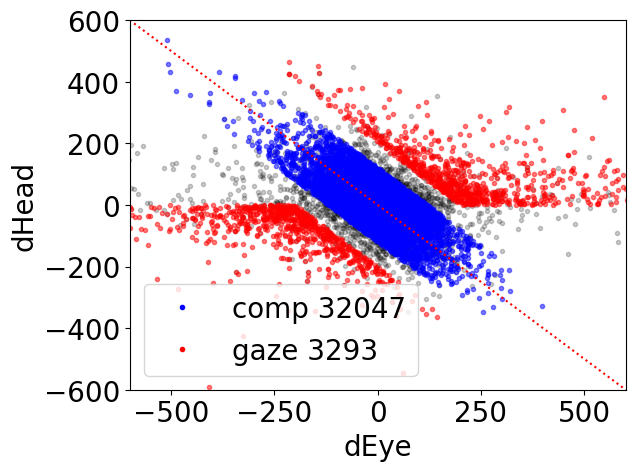

In [58]:
plt.plot(data['dEye_dps'][::20], data['dHead'][::20], 'k.',alpha = .2)
plt.plot(data['dEye_dps'][data['compL_idx']][::2], data['dHead'][data['compL_idx']][::2], 'b.',alpha = .5)
plt.plot(data['dEye_dps'][data['compR_idx']][::2], data['dHead'][data['compR_idx']][::2], 'b.',alpha = .5)
plt.plot(data['dEye_dps'][data['gazeL_idx']][::2], data['dHead'][data['gazeL_idx']][::2], 'r.',alpha = .5)
plt.plot(data['dEye_dps'][data['gazeR_idx']][::2], data['dHead'][data['gazeR_idx']][::2], 'r.',alpha = .5)

plt.xlabel('dEye')
plt.ylabel('dHead')
plt.xlim((-600,600))
plt.ylim((-600,600))
plt.plot([-600,600], [600,-600], 'r:')

comp = mlines.Line2D([], [], color='blue', marker='.', ls='', label='comp ' + str(len(data['compL_event'])+ len(data['compR_event'])))
gaze = mlines.Line2D([], [], color='red', marker='.', ls='', label='gaze '+ str(len(data['gazeL_event'])+ len(data['gazeR_event'])))
# etc etc
plt.legend(handles=[comp, gaze])

In [ ]:
plt.plot(dEye_dps[::20], dHead[::20], 'k.')
plt.xlabel('dEye')
plt.ylabel('dHead')
plt.xlim((-600,600))
plt.ylim((-600,600))
plt.plot([-600,600], [600,-600], 'r:')

In [ ]:
plt.figure()
plt.plot(data['spot_count'][0:-1:10])
plt.title('{:.3}% good'.format(np.mean(data['Usegood_reflec'])*100))
plt.ylabel('num good reflection points')
plt.xlabel('every 10th frame')

In [65]:
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec
from matplotlib.gridspec import GridSpecFromSubplotSpec
import matplotlib.lines as mlines
import pandas as pd
import os
import cv2
import matplotlib.ticker as ticker
import numpy as np
import numpy as np
from math import ceil
import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *



def gaze_shift_trials_figures_pdf(df, gazeR_event, gazeL_event, OpenephysT0, 
                                 video_paths, output_filename="output.pdf", 
                                 output_dir=None):
    """
    Creates a PDF with combined figures for each row in the pandas DataFrame.
    Each figure includes:
    -1 page trail trajectory, dEye/dHead, dHead/dGaze, cumalitive head velocity 
    - 1/2 page 3 panels showing frames from 3 videos during R gaze shifts
    - 1/2 page 3 panels showing frames from 3 videos during L gaze shifts
    
    Parameters:
    - df: pandas DataFrame containing the data
    - gazeR_event, gazeL_event: Event data
    - OpenephysT0: Time offset
    - video_paths: List of 3 video file paths
    - output_filename: str, name of the output PDF file
    - output_dir: str, directory path to save the PDF
    - frames_to_avg: number of frames before/after to average (default ±2)
    """

     # Handle output directory
    if output_dir is not None:
        os.makedirs(output_dir, exist_ok=True)
        output_path = os.path.join(output_dir, output_filename)
    else:
        output_path = output_filename
    
    # Create the PDF object
    with PdfPages(output_path) as pdf:
        fig,ax_trial = plt.subplots(2,2,figsize=(20, 15))
        
        # Iterate through each row of the DataFrame
        for ind, row in tqdm(df.iterrows()):
            # plot trial variables 
            fig,ax_trial = plt.subplots(2,2,figsize=(20, 15))

            gaze_data = process_original_plots(row, ax_trial[0,0], gazeR_event, gazeL_event, OpenephysT0)
            

            gazeR_trial_idx = gaze_data['gazeR_trial_idx']
            gazeL_trial_idx = gaze_data['gazeL_trial_idx']
            dEye_dps_trial = gaze_data['dEye_dps_trial']
            dHead_trial = gaze_data['dHead_trial']
            dGaze_trial = gaze_data['dGaze_trial']
            r_ind = gaze_data['r_ind']
            l_ind = gaze_data['l_ind']
            ts_trial_vidframes = gaze_data['ts_trial_vidframes']

          

            

            #ax_trial[0,0].plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm)
            left_gaze = mlines.Line2D([], [], color='k',
                                  markersize=15, label='left_gaze')
            right_gaze = mlines.Line2D([], [], color='red',
                                  markersize=15, label='right_gaze')
            ax_trial[0,0].legend(handles = [left_gaze,right_gaze])
            ax_trial[0,1].plot(dHead_trial,c = 'blue')
            ax_trial[0,1].plot(dEye_dps_trial,c = 'purple')
            ax_trial[0,1].legend(["dHead", "dEye"])
            ax_trial[0,1].xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))
            ax_trial[1,0].plot(dGaze_trial,c='green')
            ax_trial[1,0].plot(dHead_trial,c = 'blue')
            ax_trial[1,0].legend(["dGaze","dHead"])
            ax_trial[1,0].xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))
            ax_trial[1,1].plot(np.cumsum(dHead_trial)/60)
            ax_trial[1,1].legend(['cumlative sum dHead'])
            ax_trial[1,1].xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))

            if (r_ind == None) & (l_ind == None):
                print('no gaze')
                continue
            elif (r_ind != None) & (l_ind != None):
                print('gaze')
                #print(row.ts_head_cen_y_cm[np.array(l_ind)])
                ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)],row.ts_head_cen_y_cm[np.array(l_ind)],c='black')
                ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)],row.ts_head_cen_y_cm[np.array(r_ind)],c='red')
                ax_trial[0,1].scatter(gazeR_trial_idx,dEye_dps_trial[[gazeR_trial_idx]],c ='red')
                ax_trial[0,1].scatter(gazeL_trial_idx,dEye_dps_trial[[gazeL_trial_idx]],c ='black')
                ax_trial[1,0].scatter(gazeR_trial_idx,dGaze_trial[[gazeR_trial_idx]],c ='red')
                ax_trial[1,0].scatter(gazeL_trial_idx,dGaze_trial[[gazeL_trial_idx]],c ='black')
            elif r_ind == None:
                print('no gaze r')
                ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)],row.ts_head_cen_y_cm[np.array(l_ind)],c='black')
                ax_trial[0,1].scatter(gazeL_trial_idx,dEye_dps_trial[[gazeL_trial_idx]],c ='black')
                ax_trial[1,0].scatter(gazeL_trial_idx,dGaze_trial[[gazeL_trial_idx]],c ='black')
            elif l_ind == None:
                print('no gaze 1')
                ax_trial[0,0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)],row.ts_head_cen_y_cm[np.array(r_ind)],c='red')
                ax_trial[0,1].scatter(gazeR_trial_idx,dEye_dps_trial[[gazeR_trial_idx]],c ='red')
                ax_trial[1,0].scatter(gazeR_trial_idx,dGaze_trial[[gazeR_trial_idx]],c ='red')

            ax_trial[1,1].scatter(gazeR_trial_idx,np.cumsum(dHead_trial)[[gazeR_trial_idx]]/60,c ='red')
            ax_trial[1,1].scatter(gazeL_trial_idx,np.cumsum(dHead_trial)[[gazeL_trial_idx]]/60,c ='black')

            # Adjust layout to prevent overlap
            plt.tight_layout()
            plt.rcParams['font.size'] = 20  # Set the default font size to 12
        
        # Save this figure to the PDF
            pdf.savefig(fig, bbox_inches='tight')
        
        # Close the figure to free memory
            plt.close(fig)
            print(f"trial successfully created at: {os.path.abspath(output_path)}")

            if len(gazeR_trial_idx) == 0:
                Gaze_fig,lGaze_ax = get_averaged_frames_with_timeseries(title= 'lGaze',dEye_trial= dEye_dps_trial,dHeadTrial= dHead_trial,dGazeTrial=dGaze_trial,timeseries_idx=gazeL_trial_idx,
                                                                     timeseries_range=15, video_paths=video_paths,frame_numbers=ts_trial_vidframes[gazeL_trial_idx])
                pdf.savefig(lGaze_fig, bbox_inches='tight')
                plt.close(lGaze_fig)
                print(f"lGaze_trial successfully created at: {os.path.abspath(output_path)}")
            elif len(gazeL_trial_idx) == 0:
                rGaze_fig,rGaze_ax = get_averaged_frames_with_timeseries(title= 'rGaze',dEye_trial= dEye_dps_trial,dHeadTrial= dHead_trial,dGazeTrial=dGaze_trial,timeseries_idx=gazeR_trial_idx,timeseries_range=15,
                                                                      video_paths=video_paths,frame_numbers=ts_trial_vidframes[gazeR_trial_idx])
                pdf.savefig(rGaze_fig, bbox_inches='tight')
                plt.close(rGaze_fig)
                print(f"rGaze_trial successfully created at: {os.path.abspath(output_path)}")
            else:
        
            # rGaze 
                rGaze_fig,rGaze_ax = get_averaged_frames_with_timeseries(title= 'rGaze',dEye_trial= dEye_dps_trial,dHeadTrial= dHead_trial,dGazeTrial=dGaze_trial,timeseries_idx=gazeR_trial_idx,timeseries_range=15,
                                                                          video_paths=video_paths,frame_numbers=ts_trial_vidframes[gazeR_trial_idx])
                pdf.savefig(rGaze_fig, bbox_inches='tight')
                plt.close(rGaze_fig)
                print(f"rGaze_trial successfully created at: {os.path.abspath(output_path)}")
            # lGaze 
                lGaze_fig,lGaze_ax = get_averaged_frames_with_timeseries(title= 'lGaze',dEye_trial= dEye_dps_trial,dHeadTrial= dHead_trial,dGazeTrial=dGaze_trial,timeseries_idx=gazeL_trial_idx,
                                                                         timeseries_range=15, video_paths=video_paths,frame_numbers=ts_trial_vidframes[gazeL_trial_idx])
                pdf.savefig(lGaze_fig, bbox_inches='tight')
                plt.close(lGaze_fig)
                print(f"lGaze_trial successfully created at: {os.path.abspath(output_path)}")
            




def process_original_plots(row, ax, gazeR_event, gazeL_event, OpenephysT0):
    """Process the original plots and return gaze shift indices"""
    ## correct timestamps to ephys board 
    trial_imu_corected = row.ts_trial_timestamps - OpenephysT0
    ts_trial_vidframes = row.ts_trial_vidframes
    
    ## find frames that gaze and comp movements 
    gazeR_ind, r_ind = find_event_frames(trial_imu_corected, gazeR_event)
    gazeL_ind, l_ind = find_event_frames(trial_imu_corected, gazeL_event)
    
    ## plot trial trajectories 
    ax.plot(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm)
    left_gaze = mlines.Line2D([], [], color='k', markersize=15, label='left_gaze')
    right_gaze = mlines.Line2D([], [], color='red', markersize=15, label='right_gaze')
    ax.legend(handles=[left_gaze, right_gaze])
    ax.axis('off')

    ## plot arena and obstacle     
    plot_arena(row.to_frame().T, ax, bottom=True)
    obstacle_x = [row.gt_obstacleTL_x_cm,
                row.gt_obstacleTR_x_cm, row.gt_obstacleTR_x_cm,
                row.gt_obstacleTL_x_cm,
                row.gt_obstacleTL_x_cm]
    obstacle_y = [row.gt_obstacleTL_y_cm,
                row.gt_obstacleTL_y_cm, row.gt_obstacleBL_y_cm,
                row.gt_obstacleBL_y_cm,
                row.gt_obstacleTL_y_cm]

    ax.plot([obstacle_x[0], obstacle_x[1], obstacle_x[2], obstacle_x[3], obstacle_x[0]],
              [obstacle_y[0], obstacle_y[1], obstacle_y[2], obstacle_y[3], obstacle_y[0]], c='k')

    ## plot dgaze and head from trial     
    start_timestamp, start_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[0]))
    end_timestamp, end_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[-1]))
    dEye_dps_trial = dEye_dps[start_index:end_index]
    dHead_trial = dHead[start_index:end_index]
    dGaze_trial = dGaze[start_index:end_index]
    eyeT_trial = eyeT.flatten()[:-1][start_index:end_index]
    
    gazeL_trial_event, gazeR_trial_event, compL_trial_event, compR_trial_event, \
    gazeL_trial_idx, gazeR_trial_idx, compL_trial_idx, compR_trial_idx = classify_gaze_movements(
        dHead_trial, dGaze_trial, eyeT_trial)


    
    return {
        'dEye_dps_trial':dEye_dps_trial,
        'dHead_trial':dHead_trial,
        'dGaze_trial':dGaze_trial,
        'eyeT_trial':eyeT_trial,
        'gazeR_trial_idx': gazeR_trial_idx,
        'gazeL_trial_idx': gazeL_trial_idx,
        'trial_imu_corected': trial_imu_corected,
        'r_ind': r_ind,'l_ind':l_ind,
        'ts_trial_vidframes': ts_trial_vidframes


    }


def get_averaged_frames_with_timeseries(video_paths, frame_numbers, dEye_trial, dHeadTrial,dGazeTrial, title,
                                       timeseries_idx, timeseries_range,
                                       average_range=15, cols=4, figsize=(50, 50)):
    """
    Returns figure with video frames and time series plots using separate indexing for time series.
    
    Args:
        video_paths (list): List of video paths
        frame_numbers (list): Frame indices to plot (for videos)
        dEye_trial (np.array): Eye movement time series data
        dHeadTrial (np.array): Head movement time series data
        title (str): Title prefix for plots
        timeseries_idx (list): Indices of events in time series data
        timeseries_range (int): Range around timeseries_idx to plot
        average_range (int): Frames to average around target frame (for videos)
        cols (int): Number of columns (fixed to 4: videos + time series)
        figsize (tuple): Figure size
    
    Returns:
        fig: matplotlib figure object
        axes: 2D array of axes
    """
    if not video_paths:
        raise ValueError("At least one video path must be provided")
    if len(frame_numbers) != len(timeseries_idx):
        raise ValueError("frame_numbers and timeseries_idx must have same length")
    
    num_videos = len(video_paths)
    num_frames = len(frame_numbers)
    cols = 4  # Force 4 columns (3 videos + 1 time series)
    
    # Calculate rows needed
    rows = num_frames
    
    # Create figure with 4 columns
    fig, axes = plt.subplots(rows, cols, figsize=figsize)
    if rows == 1:
        axes = axes.reshape(1, -1)
    
    # Open video files
    caps = [cv2.VideoCapture(vp) for vp in video_paths]
    for i, cap in enumerate(caps):
        if not cap.isOpened():
            for c in caps:
                if c.isOpened():
                    c.release()
            raise ValueError(f"Could not open video at {video_paths[i]}")
    
    # Get video properties
    total_frames = [int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) for cap in caps]
    
    # Process each frame number
    for row_idx, (frame_num, ts_idx) in enumerate(zip(frame_numbers, timeseries_idx)):
        # Column 0-2: Video frames
        for vid_idx in range(num_videos):
            # Get frame range
            start_frame = max(0, frame_num - average_range)
            end_frame = min(total_frames[vid_idx]-1, frame_num + average_range)
            frame_range = list(range(start_frame, end_frame + 1))
            
            # Read and average frames
            frames = []
            for f in frame_range:
                caps[vid_idx].set(cv2.CAP_PROP_POS_FRAMES, f)
                ret, frame = caps[vid_idx].read()
                if ret:
                    frames.append(frame)
            
            # Plot video frame
            ax = axes[row_idx, vid_idx]
            if frames:
                avg_frame = cv2.cvtColor(np.mean(frames, axis=0).astype(np.uint8), cv2.COLOR_BGR2RGB)
                ax.imshow(avg_frame)
            ax.set_title(f"Video {vid_idx+1}\nFrames {start_frame}-{end_frame}\n{title} {row_idx}")
            ax.axis('off')
        
        # Column 3: Time series plot
        ts_ax = axes[row_idx, 3]
        
        # Determine time series window (ts_idx ± timeseries_range)
        ts_start = max(0, ts_idx - timeseries_range)
        ts_end = min(len(dEye_trial)-1, ts_idx + timeseries_range)
        
        # Create x-axis values centered at the event
        x_values = np.arange(ts_start, ts_end+1) - ts_idx
        
        # Plot time series
        ts_ax.plot(x_values, dEye_trial[ts_start:ts_end+1], label='Eye Movement', color='purple')
        ts_ax.plot(x_values, dHeadTrial[ts_start:ts_end+1], label='Head Movement', color='blue')
        ts_ax.plot(x_values, dGazeTrial[ts_start:ts_end+1], label='Gaze', color='green',alpha = .50)
        
        # Mark event time
        ts_ax.axvline(x=0, color='k', linestyle='--', alpha=0.5)
        ts_ax.set_title(f"Time Series\nFrames {ts_start}-{ts_end}\n{title} {row_idx}")
        ts_ax.set_xlabel("Seconds relative to event")
        ts_ax.legend()
        ts_ax.grid(True)
        ts_ax.xaxis.set_major_formatter(ticker.FuncFormatter(frames_to_seconds))
        ts_ax.set_ylim(-1000,1000)
    
    # Release video captures
    for cap in caps:
        cap.release()
    
    plt.tight_layout()
    return fig, axes

def find_event_frames(video_timestamps, event_timestamps):
    """
    Find which events occurred during the video and their corresponding video frames.
    Returns (None, None) if no events are found within the video duration.
    
    Args:
        video_timestamps (array-like): Monotonically increasing array of timestamps for each video frame.
        event_timestamps (array-like): Array of timestamps when events occurred.
        
    Returns:
        tuple: (event_indices, frame_indices) or (None, None) if no events found
               - event_indices: Indices of the original event array that fall within video duration
               - frame_indices: Corresponding video frame indices for these events
    """
    video_ts = np.asarray(video_timestamps)
    event_ts = np.asarray(event_timestamps)
    
    if len(video_ts) == 0 or len(event_ts) == 0:
        return None, None
    
    # Find which events are within video duration and their original indices
    valid_mask = (event_ts >= video_ts[0]) & (event_ts <= video_ts[-1])
    event_indices = np.where(valid_mask)[0]
    valid_events = event_ts[valid_mask]
    
    # Return None if no valid events found
    if len(valid_events) == 0:
        return None, None
    
    # Find corresponding frame indices
    frame_indices = np.searchsorted(video_ts, valid_events, side='right') - 1
    frame_indices = np.clip(frame_indices, 0, len(video_ts) - 1)
    
    return event_indices.tolist(), frame_indices.tolist()

def find_closest(array, target):
    """
    Find the element in an array that is closest to the target float value.
    
    Parameters:
    array (list): List of numbers to search through
    target (float): The target value to find the closest element to
    
    Returns:
    The element in the array closest to the target value
    """
    if  array.size == 0:  # Handle empty array case
        raise ValueError("Input array must not be empty")
    
    # Initialize with first element
    closest = array[0]
    min_diff = abs(target - closest)
    
    for element in array[1:]:
        current_diff = abs(target - element)
        if current_diff < min_diff:
            min_diff = current_diff
            closest = element
    
    return closest,np.argwhere(array==closest)[0][0]

def frames_to_seconds(x, pos,fps = 60):
    return f"{x / fps:.2f}"

In [ ]:
def frames_to_seconds(x, pos,fps = 60):
    return f"{x / fps:.2f}"

0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf


1it [00:50, 50.52s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf


2it [00:59, 26.17s/it]

...

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf


4it [01:29, 19.04s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf


5it [01:39, 20.00s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new_test.pdf


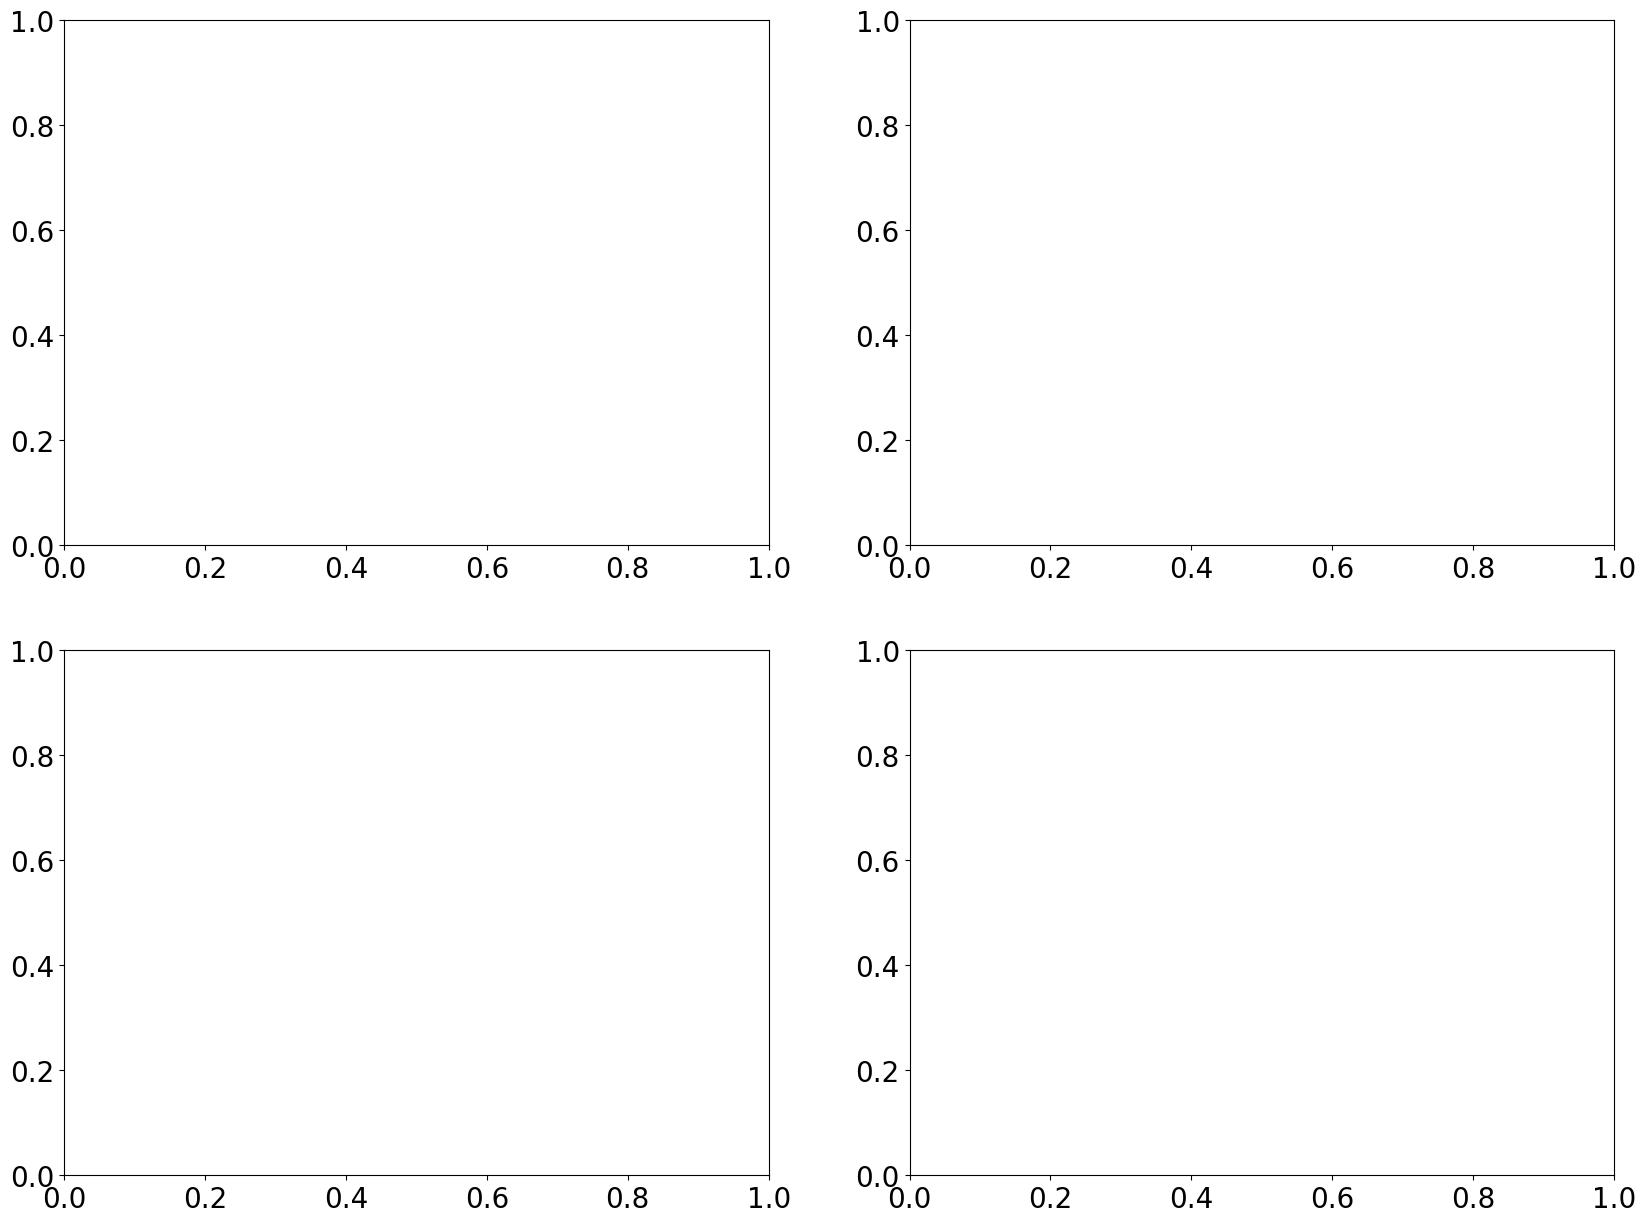

In [64]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
test = df1.sample(5)
gaze_shift_trials_figures_pdf(
    df =  test, gazeR_event=gazeR_event, gazeL_event=gazeL_event, OpenephysT0=OpenephysT0,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="050725_F3LILT_gaze_analysis_new_test.pdf"  # Average ±2 frames around the target
)

In [2]:
import matplotlib as plt

NameError: name 'dHead' is not defined

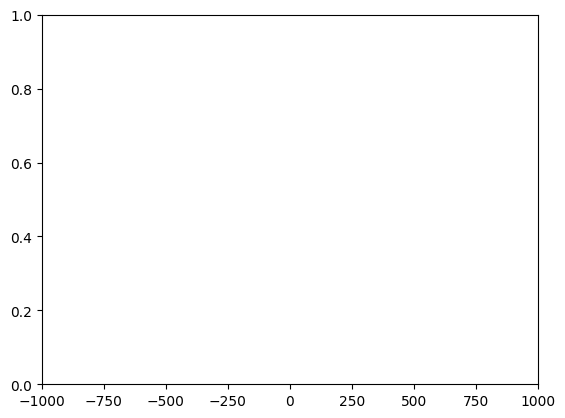

In [6]:
fig,ax = plt.subplots()
ax.set_xlim(-1000,1000)
ax.hist(dHead, density=True,bins=30)
ax.set_title('dHead')
    


0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf


1it [00:20, 20.73s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf


2it [00:32, 15.41s/it]

...

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf


121it [39:34, 54.63s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf


122it [39:48, 19.58s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis_new.pdf


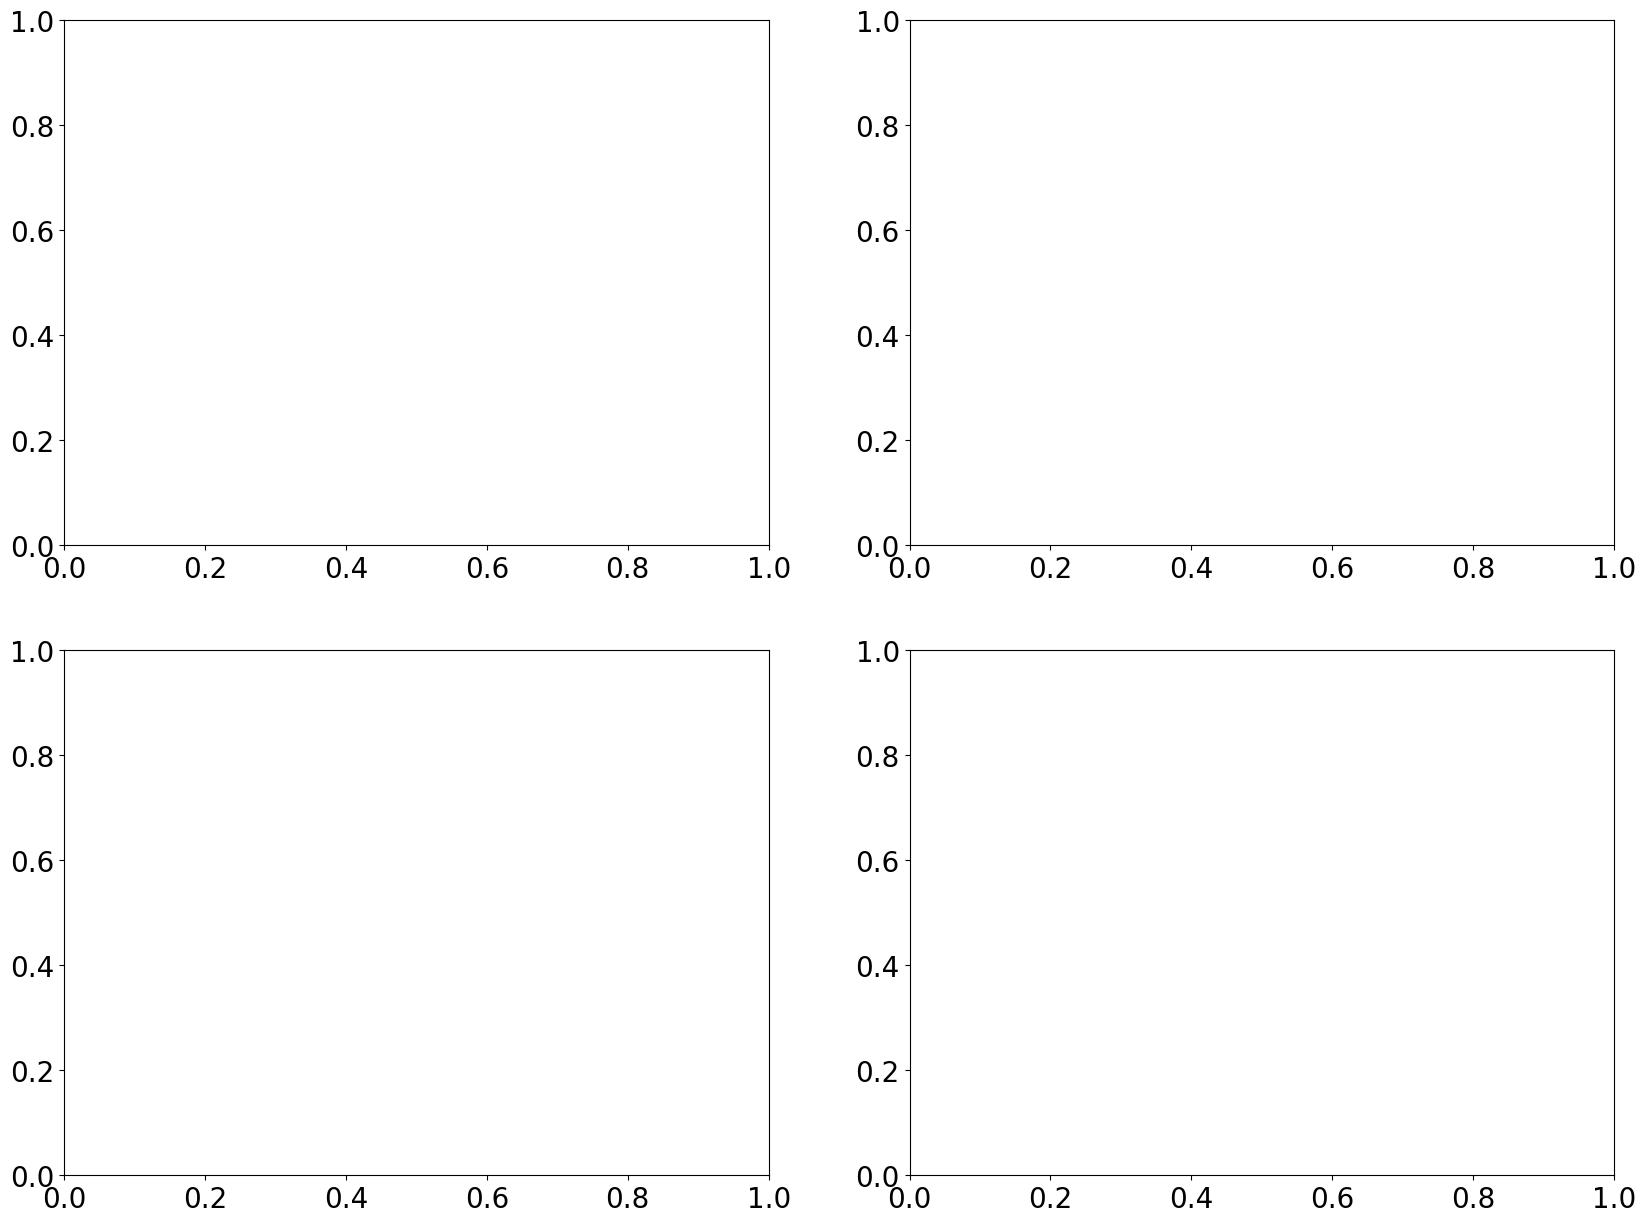

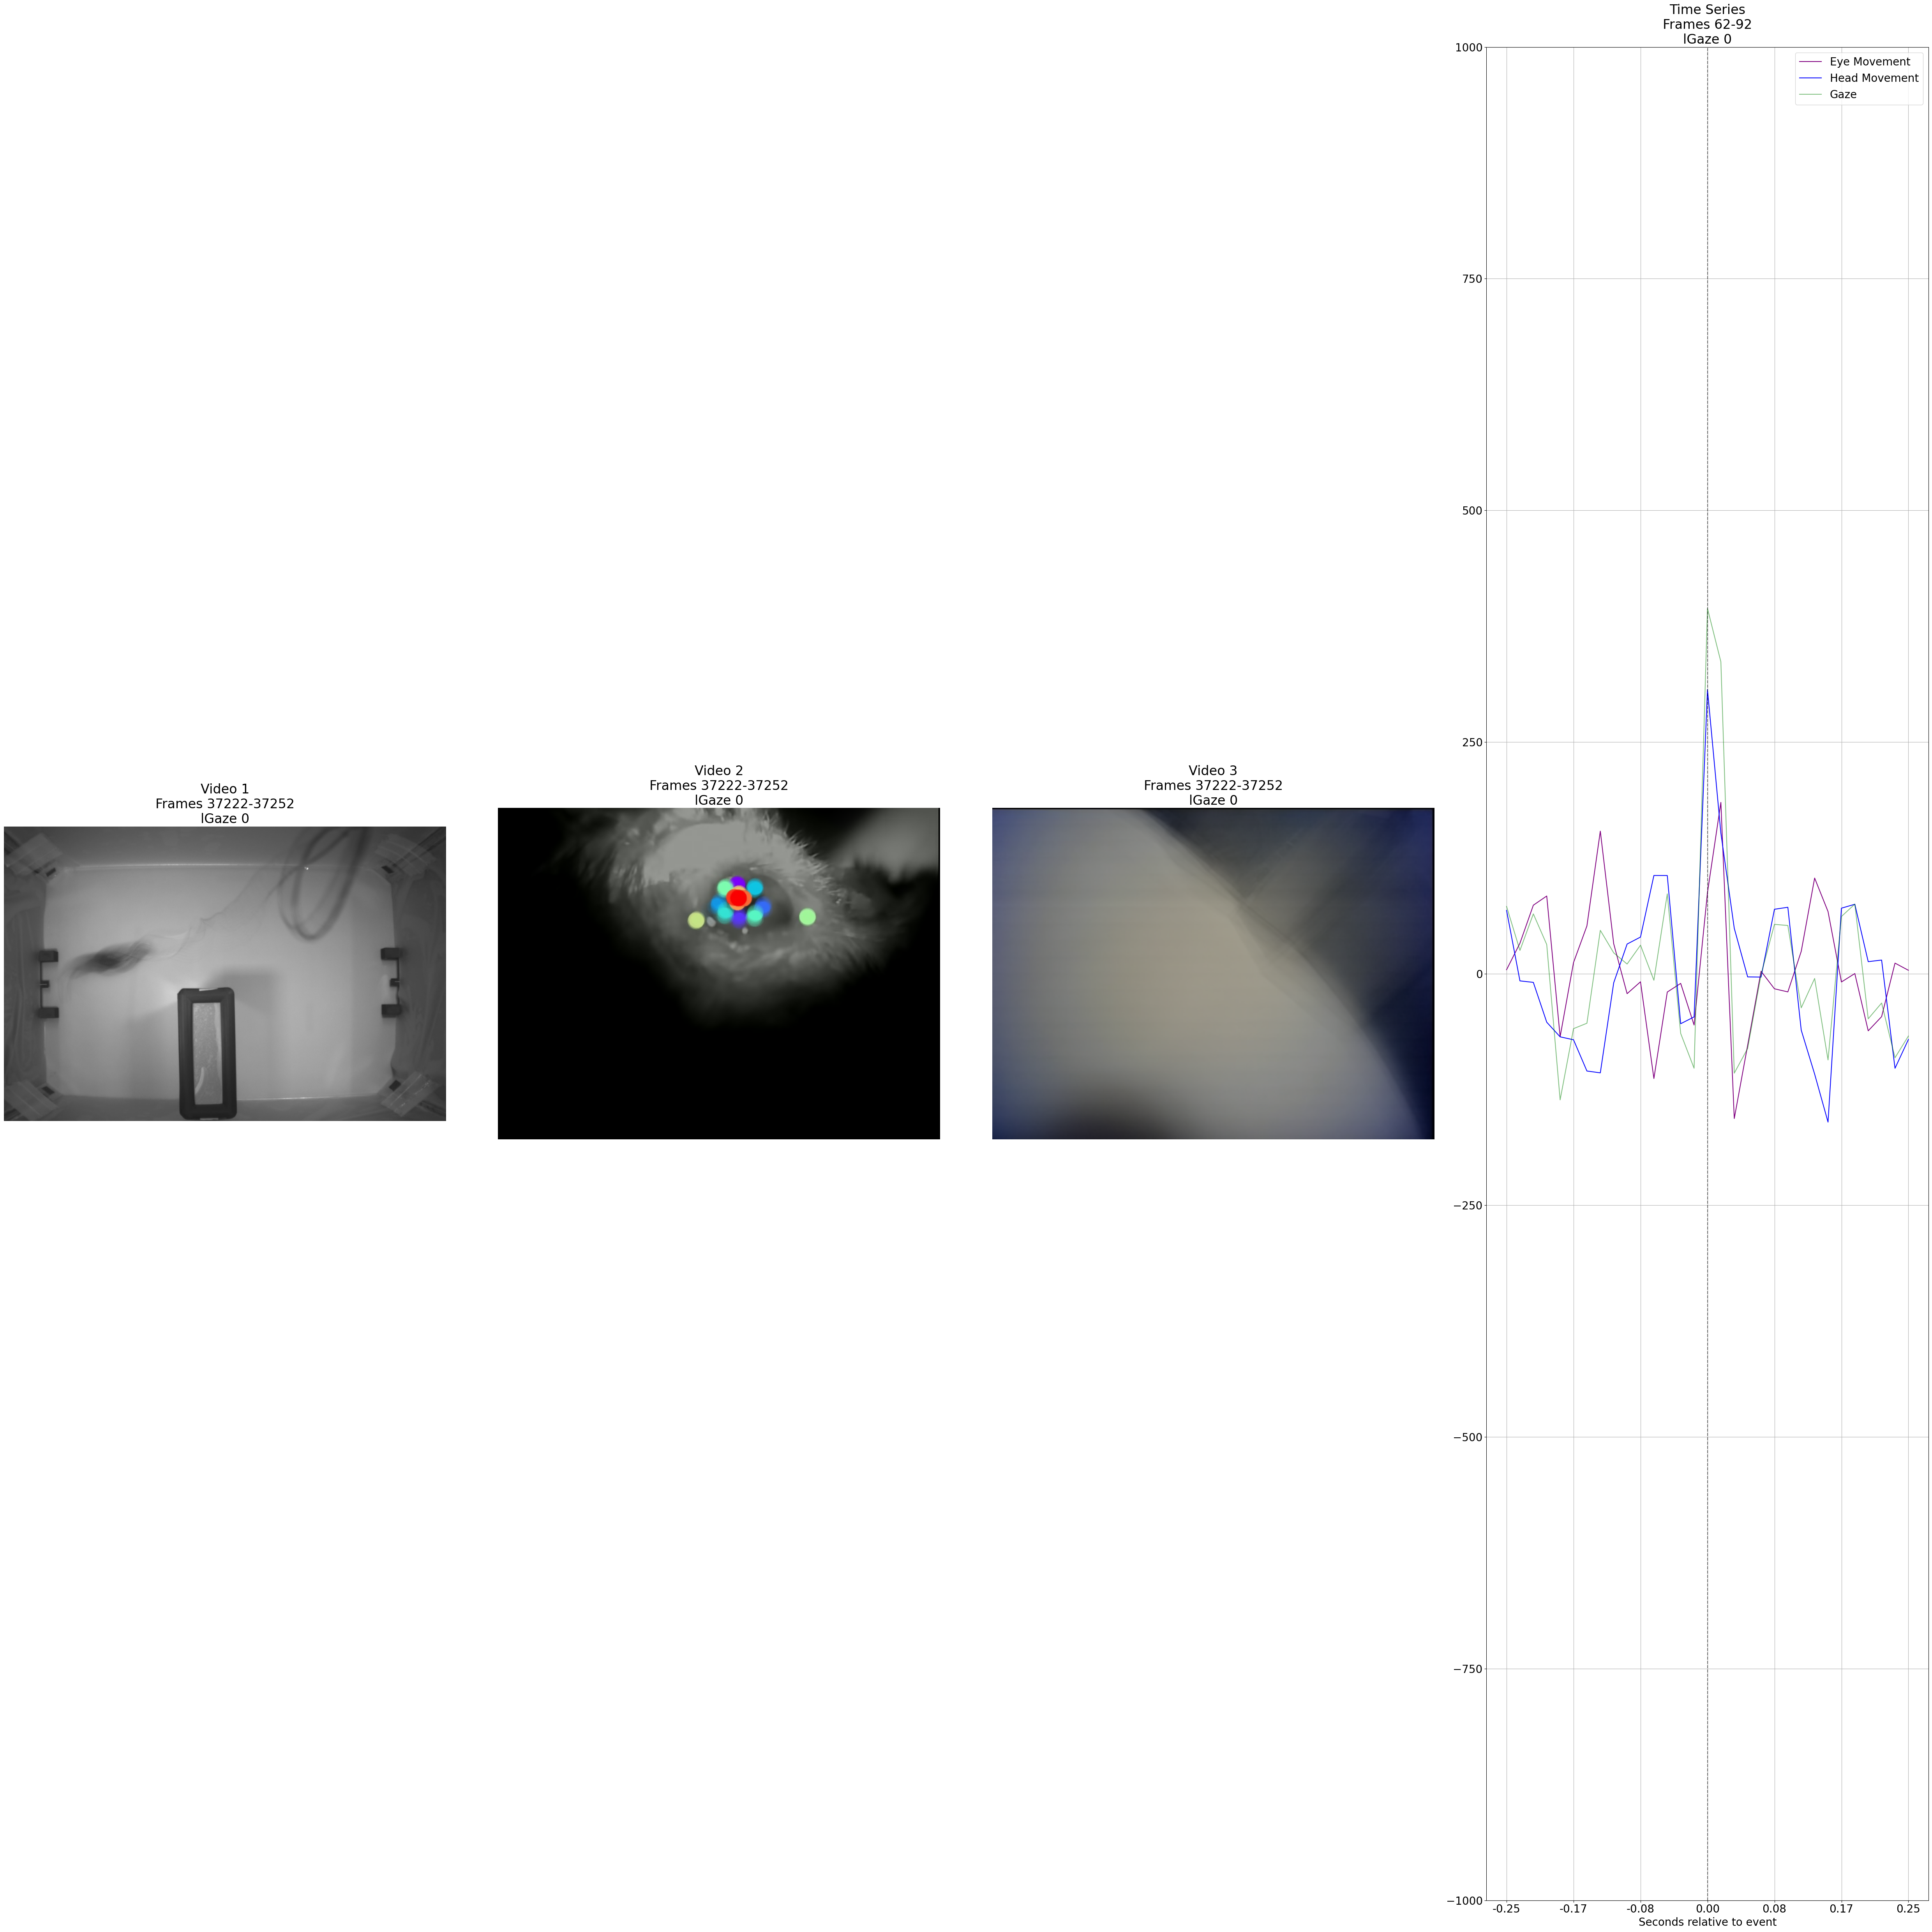

In [66]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]

gaze_shift_trials_figures_pdf(
    df =  df1, gazeR_event=gazeR_event, gazeL_event=gazeL_event, OpenephysT0=OpenephysT0,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="050725_F3LILT_gaze_analysis_new.pdf"  # Average ±2 frames around the target
)

In [ ]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
df_test = df1.sample(1)
gaze_shift_trials_figures_pdf(
    df =  df_test, gazeR_event=gazeR_event, gazeL_event=gazeL_event, OpenephysT0=OpenephysT0,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="gaze_analysis.pdf"  # Average ±2 frames around the target
)

In [ ]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
df_test = df1.sample(10)
gaze_shift_trials_figures_pdf(
    df =  df_test, gazeR_event=gazeR_event, gazeL_event=gazeL_event, OpenephysT0=OpenephysT0,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="gaze_analysis.pdf"  # Average ±2 frames around the target
    )

In [ ]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]
df_test = df1.sample(2)
gaze_shift_trials_figures_pdf(
    df =  df_test, gazeR_event=gazeR_event, gazeL_event=gazeL_event, OpenephysT0=OpenephysT0,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="gaze_analysis.pdf"  # Average ±2 frames around the target
    )

In [ ]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\050725_F3LITT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\050725_F3LITT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam\050725_F3LITT_control_Rig2_oa_cam_WORLDdeinter.avi"
]

gaze_shift_trials_figures_pdf(
    df =  df1, gazeR_event=gazeR_event, gazeL_event=gazeL_event, OpenephysT0=OpenephysT0,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LITT\oa_cam",
    video_paths=video_paths, output_filename="050725_F3LITT_gaze_analysis.pdf"  # Average ±2 frames around the target
)

0it [00:00, ?it/s]

gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf


1it [00:25, 25.29s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf


2it [00:37, 17.60s/it]

...

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf


121it [54:57, 66.80s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf
gaze
trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf
rGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf


122it [55:17, 27.19s/it]

lGaze_trial successfully created at: \\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_gaze_analysis.pdf


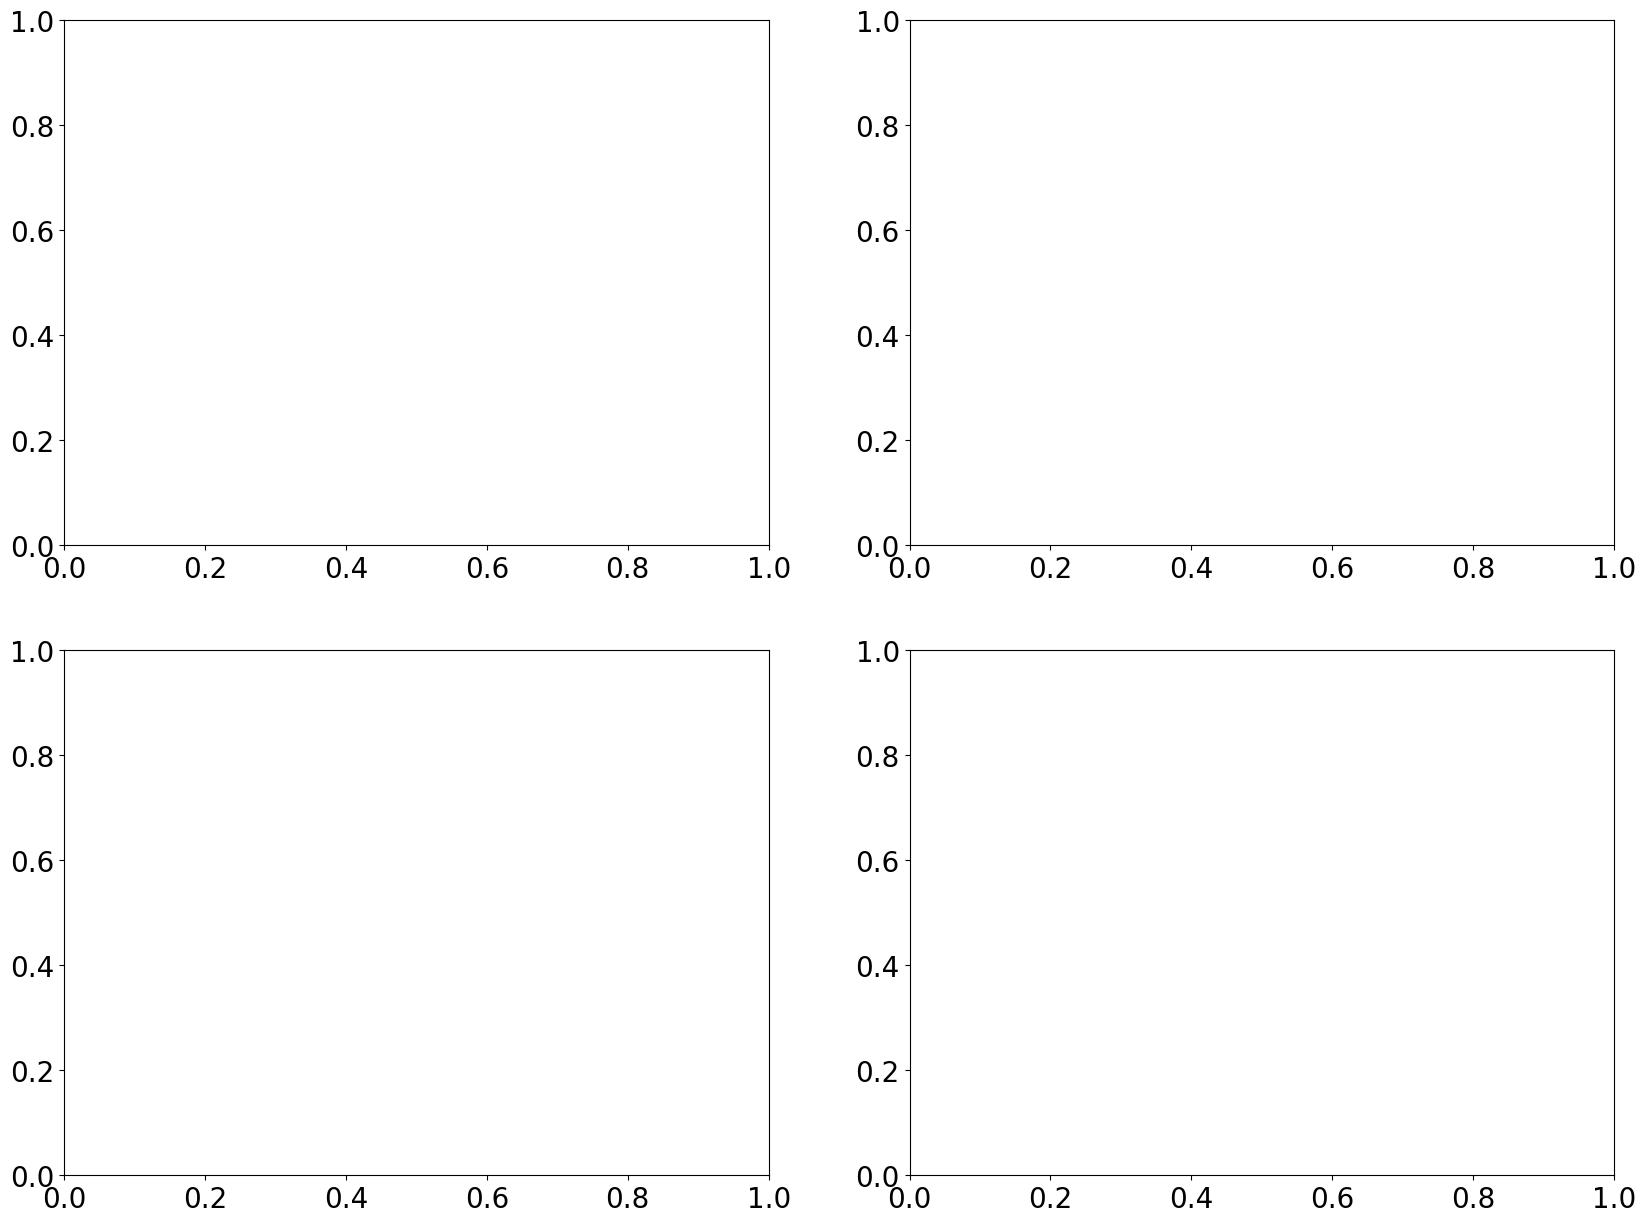

In [131]:
video_paths = [
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_TOP1.avi",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_REYEdeinterDLC_resnet50_eye_tracking_041525Apr15shuffle1_1030000_labeled.mp4",
    r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam\050725_F3LILT_control_Rig2_oa_cam_WORLDdeinter.avi"
]

gaze_shift_trials_figures_pdf(
    df =  df1, gazeR_event=gazeR_event, gazeL_event=gazeL_event, OpenephysT0=OpenephysT0,output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam",
    video_paths=video_paths, output_filename="050725_F3LILT_gaze_analysis.pdf"  # Average ±2 frames around the target
)

In [ ]:
plt.figure()
plt.hist(pupil_count, bins=9,
                range=(0,9), density=True)
plt.xlabel('num good eye points')
plt.ylabel('fraction of frames')

In [ ]:
gaze_shift_trials_figures_pdf(trial,gazeR_event,gazeL_event,OpenephysT0,output_filename="test.pdf", output_dir=r"\\goeppert\Vol2\mike\recordings\050725\F3LILT\oa_cam")

In [ ]:
for ind,row in df.iterrows():
    trial_imu_corected = row.ts_trial_timestamps - OpenephysT0

    gazeR_ind,r_ind = find_event_frames(trial_imu_corected, gazeR_event)
    gazeL_ind ,l_ind = find_event_frames(trial_imu_corected, gazeL_event)
    fig,axis = plt.subplots(2,figsize =[8,12])
    axis[0].plot(row.ts_head_cen_x_cm,row.ts_head_cen_y_cm)   

    
    plot_arena(trial,axis[0],bottom=True)
    obstacle_x = [row.gt_obstacleTL_x_cm,
        row.gt_obstacleTR_x_cm,row.gt_obstacleTR_x_cm,
        row.gt_obstacleTL_x_cm,
        row.gt_obstacleTL_x_cm]
    obstacle_y = [row.gt_obstacleTL_y_cm,
        row.gt_obstacleTL_y_cm,row.gt_obstacleBL_y_cm,
        row.gt_obstacleBL_y_cm,
        row.gt_obstacleTL_y_cm]
    
    axis[0].plot([obstacle_x[0],obstacle_x[1],obstacle_x[2],obstacle_x[3],obstacle_x[0]],
                              [obstacle_y[0],obstacle_y[1],obstacle_y[2],obstacle_y[3],obstacle_y[0]],c='k')
    
    if (r_ind == None) & (l_ind == None):
        continue
    elif (r_ind != None) & (l_ind != None):
        axis[0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)-1],row.ts_head_cen_y_cm[np.array(l_ind)-1],c='black')
        axis[0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)-1],row.ts_head_cen_y_cm[np.array(r_ind)-1],c='red')

    elif r_ind == None:
        axis[0].scatter(row.ts_head_cen_x_cm[np.array(l_ind)-1],row.ts_head_cen_y_cm[np.array(l_ind)-1],c='black')
    elif l_ind == None:
        axis[0].scatter(row.ts_head_cen_x_cm[np.array(r_ind)-1],row.ts_head_cen_y_cm[np.array(r_ind)-1],c='red')
   

    


    #trial_imu_corected = row.ts_trial_timestamps - OpenephysT0
    start_timestamp, start_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[0]))
    end_timestamp, end_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[-1]))
    dEye_dps_trial = dEye_dps[start_index:end_index]
    dHead_trial = dHead[start_index:end_index]
    dGaze_trial = dGaze[start_index:end_index]
    eyeT_trial = eyeT.flatten()[:-1][start_index:end_index]
    gazeL_trial_event, gazeR_trial_event, compL_trial_event, compR_trial_event,gazeL_trial_idx, gazeR_trial_idx, compL_trial_idx, compR_trial_idx = classify_gaze_movements(dHead_trial, dGaze_trial, eyeT_trial,)
    axis[1].plot(dGaze_trial)
    axis[1].plot(dHead_trial)
    axis[1].scatter(gazeR_trial_idx,dGaze_trial[[gazeR_trial_idx]],c ='red')
    axis[1].scatter(gazeL_trial_idx,dGaze_trial[[gazeL_trial_idx]],c ='black')


In [ ]:
import numpy as np

def classify_gaze_movements(dHead_trial, dGaze_trial, eyeT_trial, 
                            shifted_head=60, still_gaze=120, shifted_gaze=200):
    """
    Classify gaze movements into left/right gaze shifts and left/right compensatory movements.
    
    Parameters:
    - dHead_trial: Array of head movement values
    - dGaze_trial: Array of gaze movement values
    - eyeT_trial: Array of eye timestamps
    - shifted_head: Threshold for head movement (default 60)
    - still_gaze: Threshold for stationary gaze (default 120)
    - shifted_gaze: Threshold for gaze shift (default 200)
    
    Returns:
    - gazeL_trial_event: Left gaze shift events
    - gazeR_trial_event: Right gaze shift events
    - compL_trial_event: Left compensatory events
    - compR_trial_event: Right compensatory events
    - gazeL_idx: Indices of left gaze shifts in original array
    - gazeR_idx: Indices of right gaze shifts in original array
    - compL_idx: Indices of left compensatory movements in original array
    - compR_idx: Indices of right compensatory movements in original array
    """
    # Classify movements
    gazeL_trial = eyeT_trial[(dHead_trial > shifted_head) &         \
                 (dGaze_trial > shifted_gaze)]
    gazeR_trial = eyeT_trial[(dHead_trial < -shifted_head) &        \
                     (dGaze_trial < -shifted_gaze)]

    compL_trial = eyeT_trial[(dHead_trial > shifted_head) &         \
                     (dGaze_trial < still_gaze) &           \
                     (dGaze_trial > -still_gaze)]
    compR_trial = eyeT_trial[(dHead_trial < -shifted_head) &        \
                     (dGaze_trial > -still_gaze) &          \
                     (dGaze_trial < still_gaze)]


    # Eliminating compensatory eye/head movements which fall right after gaze-shifting eye/head movements
    compL_trial = drop_nearby_events(compL_trial, gazeL_trial)  
    compR_trial = drop_nearby_events(compR_trial, gazeR_trial)

    # Eliminate saccades repeated over sequential camera frames
    gazeL_trial_event = drop_repeat_events(gazeL_trial)
    gazeR_trial_event = drop_repeat_events(gazeR_trial)
    compL_trial_event = drop_repeat_events(compL_trial)
    compR_trial_event = drop_repeat_events(compL_trial)

    # Extract idx

    _, gazeL_trial_idx, _ = np.intersect1d(eyeT_trial,gazeL_trial_event, return_indices=True)
    _, gazeR_trial_idx, _ = np.intersect1d(eyeT_trial,gazeR_trial_event, return_indices=True)
    _, compL_trial_idx, _ = np.intersect1d(eyeT_trial,compL_trial_event, return_indices=True)
    _, compR_trial_idx, _ = np.intersect1d(eyeT_trial,compR_trial_event, return_indices=True)
    
    return gazeL_trial_event, gazeR_trial_event, compL_trial_event, compR_trial_event,gazeL_trial_idx, gazeR_trial_idx, compL_trial_idx, compR_trial_idx

In [ ]:
gazeL_trial_event, gazeR_trial_event, compL_trial_event, compR_trial_event,gazeR_trial_idx, gazeL_trial_idx, compL_trial_idx, compR_trial_idx = classify_gaze_movements(dHead_trial, dGaze_trial, eyeT_trial,)

In [ ]:
shifted_head = 60
still_gaze = 120
shifted_gaze = 200

gazeL_trial = eyeT_trial[(dHead_trial > shifted_head) &         \
                 (dGaze_trial > shifted_gaze)]
gazeR_trial = eyeT_trial[(dHead_trial < -shifted_head) &        \
                 (dGaze_trial < -shifted_gaze)]

compL_trial = eyeT_trial[(dHead_trial > shifted_head) &         \
                 (dGaze_trial < still_gaze) &           \
                 (dGaze_trial > -still_gaze)]
compR_trial = eyeT_trial[(dHead_trial < -shifted_head) &        \
                 (dGaze_trial > -still_gaze) &          \
                 (dGaze_trial < still_gaze)]


# Eliminating compensatory eye/head movements which fall right after gaze-shifting eye/head movements
compL_trial = drop_nearby_events(compL_trial, gazeL_trial)  
compR_trial = drop_nearby_events(compR_trial, gazeR_trial)

# Eliminate saccades repeated over sequential camera frames
gazeL_trial_event = drop_repeat_events(gazeL_trial)
gazeR_trial_event = drop_repeat_events(gazeR_trial)
compL_trial_event = drop_repeat_events(compL_trial)
compR_trial_event = drop_repeat_events(compL_trial)

# Extract idx

_, gazeL_trial_idx, _ = np.intersect1d(eyeT_trial,gazeL_trial_event, return_indices=True)
_, gazeR_trial_idx, _ = np.intersect1d(eyeT_trial,gazeR_trial_event, return_indices=True)
_, compL_trial_idx, _ = np.intersect1d(eyeT_trial,compL_trial_event, return_indices=True)
_, compR_trial_idx, _ = np.intersect1d(eyeT_trial,compR_trial_event, return_indices=True)

print(gazeL_trial_event,gazeR_trial_event)
print(l_ind,r_ind)

In [ ]:
print(gazeL_trial_event,gazeR_trial_event)
print(l_ind,r_ind)

In [ ]:
row.ts_trial_timestamps-OpenephysT0

In [ ]:
shifted_head = 60
still_gaze = 120
shifted_gaze = 240

In [ ]:
plt.plot(dGaze_trial)
plt.plot(dHead_trial)
[plt.axhline(y=i, linestyle='--') for i in [60,120,200,-120,-200]]


In [ ]:
plt.plot(dEye_dps_trial)
plt.plot(dHead_trial)

In [ ]:
plt.imshow(frames[0])


In [ ]:
plt.imshow(rframes[0])


In [ ]:
row['trial_vidframes']

In [ ]:
row['ts_trial_vidframes']

In [ ]:
row['trial_vidframes']

In [ ]:
print(l_ind,r_ind)

In [ ]:
vidpath = r"\\goeppert\Vol2\mike\recordings\042525\F3LITT\oa_cam1\042525_F3LITT_control_Rig2_oa_cam1_TOP1.avi"
rframe_indices = row['ts_trial_vidframes'][r_ind]
rframes = extract_frames(vidpath, rframe_indices)

In [ ]:
vidpath = r"\\goeppert\Vol2\mike\recordings\042525\F3LITT\oa_cam1\042525_F3LITT_control_Rig2_oa_cam1_TOP1.avi"
frame_indices = row['ts_trial_vidframes'][l_ind]
frames = extract_frames(vidpath, frame_indices)

In [ ]:
import cv2
import numpy as np

def extract_frames(video_path, frame_indices):
    """
    Extract specific frames from a video file using OpenCV.
    
    Args:
        video_path (str): Path to the video file
        frame_indices (list): List of frame indices to extract (0-based)
        
    Returns:
        list: List of extracted frames as numpy arrays (BGR format)
    """
    # Open the video file
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        raise ValueError(f"Could not open video file: {video_path}")
    
    frames = []
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    # Sort and remove duplicates from frame_indices
    frame_indices = sorted(set(frame_indices))
    
    for frame_idx in frame_indices:
        # Check if frame index is valid
        if frame_idx < 0 or frame_idx >= total_frames:
            print(f"Warning: Frame index {frame_idx} is out of range (0-{total_frames-1})")
            continue
        
        # Set the video position to the desired frame
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        
        # Read the frame
        ret, frame = cap.read()
        
        if ret:
            frames.append(frame)
        else:
            print(f"Warning: Could not read frame {frame_idx}")
    
    # Release the video capture object
    cap.release()
    
    return frames

In [ ]:
import numpy as np

def find_event_frames(video_timestamps, event_timestamps):
    """
    Find which events occurred during the video and their corresponding video frames.
    
    Args:
        video_timestamps (array-like): Monotonically increasing array of timestamps for each video frame.
        event_timestamps (array-like): Array of timestamps when events occurred.
        
    Returns:
        tuple: (event_indices, frame_indices)
               - event_indices: Indices of the original event array that fall within video duration
               - frame_indices: Corresponding video frame indices for these events
    """
    video_ts = np.asarray(video_timestamps)
    event_ts = np.asarray(event_timestamps)
    
    # Find which events are within video duration and their original indices
    valid_mask = (event_ts >= video_ts[0]) & (event_ts <= video_ts[-1])
    event_indices = np.where(valid_mask)[0]
    valid_events = event_ts[valid_mask]
    
    # Find corresponding frame indices
    frame_indices = []
    if len(valid_events) > 0:
        frame_indices = np.searchsorted(video_ts, valid_events, side='right') - 1
        frame_indices = np.clip(frame_indices, 0, len(video_ts) - 1)
    
    return event_indices.tolist(), frame_indices.tolist()

# Example Usage
video_ts = [0.0, 0.033, 0.066, 0.1, 0.133]  # 5 frames
event_ts = [-0.1, 0.01, 0.05, 0.07, 0.12, 0.15, 0.2]  # 7 events

event_indices, frame_indices = find_event_frames(video_ts, event_ts)

print("Original event indices:", event_indices)  # [1, 2, 3, 4, 5]
print("Corresponding frame indices:", frame_indices)  # [0, 1, 2, 3, 3]

In [ ]:
import numpy as np

def find_event_frames(video_timestamps, event_timestamps):
    """
    Find which events occurred during the video and their corresponding video frames.
    Returns (None, None) if no events are found within the video duration.
    
    Args:
        video_timestamps (array-like): Monotonically increasing array of timestamps for each video frame.
        event_timestamps (array-like): Array of timestamps when events occurred.
        
    Returns:
        tuple: (event_indices, frame_indices) or (None, None) if no events found
               - event_indices: Indices of the original event array that fall within video duration
               - frame_indices: Corresponding video frame indices for these events
    """
    video_ts = np.asarray(video_timestamps)
    event_ts = np.asarray(event_timestamps)
    
    if len(video_ts) == 0 or len(event_ts) == 0:
        return None, None
    
    # Find which events are within video duration and their original indices
    valid_mask = (event_ts >= video_ts[0]) & (event_ts <= video_ts[-1])
    event_indices = np.where(valid_mask)[0]
    valid_events = event_ts[valid_mask]
    
    # Return None if no valid events found
    if len(valid_events) == 0:
        return None, None
    
    # Find corresponding frame indices
    frame_indices = np.searchsorted(video_ts, valid_events, side='right') - 1
    frame_indices = np.clip(frame_indices, 0, len(video_ts) - 1)
    
    return event_indices.tolist(), frame_indices.tolist()

# Example Usage
if __name__ == "__main__":
    # Case 1: Events found
    video_ts = [0.0, 0.033, 0.066, 0.1, 0.133]
    event_ts = [0.01, 0.05, 0.07, 0.12]
    event_idx, frame_idx = find_event_frames(video_ts, event_ts)
    print("Case 1 - Events found:")
    print("Event indices:", event_idx)  # [0, 1, 2, 3]
    print("Frame indices:", frame_idx)  # [0, 1, 2, 3]
    
    # Case 2: No events found (all before)
    event_ts = [-0.1, -0.05]
    event_idx, frame_idx = find_event_frames(video_ts, event_ts)
    print("\nCase 2 - No events found (all before):")
    print("Result:", (event_idx, frame_idx))  # (None, None)
    
    # Case 3: No events found (all after)
    event_ts = [0.2, 0.25]
    event_idx, frame_idx = find_event_frames(video_ts, event_ts)
    print("\nCase 3 - No events found (all after):")
    print("Result:", (event_idx, frame_idx))  # (None, None)
    
    # Case 4: Empty input
    event_idx, frame_idx = find_event_frames([], [])
    print("\nCase 4 - Empty input:")
    print("Result:", (event_idx, frame_idx))  # (None, None)

In [ ]:
keys = ['head_cen','leftear','rightear','spine','midspine','tailbase','trial_timestamps']
keys_list = list_columns(df1,keys)
keys_list= [col for col in keys_list if 'likelihood' not in col]
keys_list= [col for col in keys_list if 'lind' not in col]

In [ ]:

plt.figure()
plt.plot(spot_count[0:-1:10])
plt.title('{:.3}% good'.format(np.mean(likelihood)*100))
plt.ylabel('num good reflection points')
plt.xlabel('every 10th frame')

In [ ]:
plt.figure()
plt.hist(pupil_count, bins=9,
                range=(0,9), density=True)
plt.xlabel('num good eye points')
plt.ylabel('fraction of frames')